# Sentinel — 04: NLP Agent

**Bu notebook'ta yapılacaklar:**
1. Hasta notlarını Claude Haiku ile analiz et
2. Gizli risk faktörlerini çıkar
3. Cache sistemi
4. Demo hasta analizi
5. Agent çıktısını Sentinel skoruna entegre et

In [2]:
import sys
!{sys.executable} -m pip install anthropic

  Using cached anthropic-0.84.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
Using cached anthropic-0.84.0-py3-none-any.whl (455 kB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)

   ------------- -------------------------- 1/3 [distro]
   ------------- -------------------------- 1/3 [distro]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 [anthropic]
   -------------------------- ------------- 2/3 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\Mutlu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import duckdb, pandas as pd, numpy as np
import json, os, pickle, hashlib, warnings
warnings.filterwarnings('ignore')
import anthropic
from dotenv import load_dotenv

# .env dosyasını yükle
load_dotenv()

# Değişkenleri ortamdan çek
DB_PATH      = os.getenv('DB_PATH')
MODEL_PATH   = os.getenv('MODEL_PATH')
CACHE_PATH   = os.getenv('CACHE_PATH')
ANTHROPIC_API_KEY = os.getenv('ANTHROPIC_API_KEY')

DEMO_HASTA = 'ANON_018774'

# Kontrol (Opsiyonel ama hayat kurtarır)
if not ANTHROPIC_API_KEY:
    raise ValueError("Hata: ANTHROPIC_API_KEY bulunamadı. .env dosyasını kontrol et!")

client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
con    = duckdb.connect(DB_PATH)

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r', encoding='utf-8') as f:
        nlp_cache = json.load(f)
else:
    nlp_cache = {}

print(f'Bağlantı kuruldu. Cache: {len(nlp_cache)} kayıt')

Bağlantı kuruldu. Cache: 5 kayıt


## BOLUM 1: Hasta Notlarini Cek

In [2]:
def hasta_notlari_cek(hasta_id, con):
    df = con.execute(f"""
        SELECT CAST(EPISODE_TARIH AS DATE) AS tarih, SERVISADI,
               YAKINMA, "Muayene Notu", "Tedavi Notu",
               "Özgeçmiş Notu", "Sürekli Kullandığı İlaçlar", Sigara, Alkol
        FROM ana
        WHERE HASTA_ID = '{hasta_id}'
          AND (YAKINMA IS NOT NULL OR "Muayene Notu" IS NOT NULL
               OR "Özgeçmiş Notu" IS NOT NULL)
        ORDER BY EPISODE_TARIH DESC LIMIT 20
    """).fetchdf()
    if len(df) == 0:
        return ''
    parcalar = []
    for _, row in df.iterrows():
        p = f"[{row['tarih']} - {row['SERVISADI']}]\n"
        for col in df.columns[2:]:
            val = row.get(col)
            if pd.notna(val) and str(val).strip() not in ['', 'nan', 'None']:
                p += f"{col}: {str(val)[:200]}\n"
        parcalar.append(p)
    return '\n'.join(parcalar)

notlar = hasta_notlari_cek(DEMO_HASTA, con)
print(f'Not uzunlugu: {len(notlar)} karakter')
print(notlar[:500])

Not uzunlugu: 8132 karakter
[2025-05-10 00:00:00 - Üroloji]
YAKINMA: ALT ÜRİNER SİSTEM YAKINMALARI VAR. SON 1 AYDA ORTA
Muayene Notu: UF: 12/8/232, PMR 118 ML, KESİKLİ İDRAR AKIMI
PSA: 2.7
USG: PROSTAT 54 GR.
Tedavi Notu: XATRAL XL TB - 1 AY 
UF TEKRARINA GÖRE MEDİKAL /CERRAHİ TEDAVİ KARARI VERİLECEK

[2025-05-10 00:00:00 - Üroloji]
Muayene Notu: N
Tedavi Notu: kinzy pyeloseptyl

[2025-05-10 00:00:00 - Üroloji]
Muayene Notu: N
Tedavi Notu: ciproxin

[2025-05-10 00:00:00 - Üroloji]
Muayene Notu: Prostat grade1 benign
Tedavi


## BOLUM 2: Claude Haiku NLP Agent

In [3]:
SYSTEM_PROMPT = '''Sen Acıbadem Sentinel sisteminin klinik NLP motorusun.
Hasta klinik notlarını analiz ederek yapılandırılmış risk faktörleri çıkarıyorsun.

GOREV: Notlardaki gizli risk faktörlerini tespit et. Aktif vs gecmis ayırt et.

CIKTI: Sadece JSON, baska hicbir sey yazma:
{
  "risk_faktorleri": [
    {"kategori": "GIS", "bulgu": "mide kanamas ozgecmisi", "aktif": false, "ciddiyet": "yuksek"}
  ],
  "kontrendikasyon_uyarilari": [
    {"ilac_grubu": "NSAii", "neden": "GIS kanama riski", "ciddiyet": "kritik"}
  ],
  "klinik_ozet": "3 maddelik ozet",
  "nlp_risk_skoru": 75,
  "acil_bayraklar": []
}'''

def nlp_agent_analiz(hasta_id, nota, cache=None):
    cache_key = hashlib.md5(f'{hasta_id}:{nota[:200]}'.encode()).hexdigest()
    if cache and cache_key in cache:
        print(f'  Cache hit: {hasta_id}')
        return cache[cache_key]
    if not nota or len(nota.strip()) < 50:
        return {'risk_faktorleri':[],'kontrendikasyon_uyarilari':[],
                'klinik_ozet':'Yeterli not yok.','nlp_risk_skoru':50,'acil_bayraklar':[]}
    print(f'  API cagrisi: {hasta_id}...')
    try:
        resp = client.messages.create(
            model='claude-haiku-4-5-20251001', max_tokens=1000,
            system=SYSTEM_PROMPT,
            messages=[{'role':'user','content':f'Analiz et:\n\n{nota[:3000]}'}]
        )
        yanit = resp.content[0].text.strip()
        if '```' in yanit:
            yanit = yanit.split('```')[1].replace('json','').strip()
        sonuc = json.loads(yanit)
        if cache is not None:
            cache[cache_key] = sonuc
            with open(CACHE_PATH,'w',encoding='utf-8') as f:
                json.dump(cache, f, ensure_ascii=False, indent=2)
        return sonuc
    except Exception as e:
        print(f'  Hata: {e}')
        return None

print('nlp_agent_analiz() hazir')

nlp_agent_analiz() hazir


## BOLUM 3: Demo Hasta Analizi

In [4]:
print(f'=== NLP AGENT: {DEMO_HASTA} ===')
notlar = hasta_notlari_cek(DEMO_HASTA, con)
agent_sonuc = nlp_agent_analiz(DEMO_HASTA, notlar, nlp_cache)

if agent_sonuc:
    print(f'\nKLINIK OZET: {agent_sonuc.get("klinik_ozet","-")}')
    print(f'\nRISK FAKTORLERI:')
    for rf in agent_sonuc.get('risk_faktorleri', []):
        aktif = 'AKTIF' if rf.get('aktif') else 'GECMIS'
        print(f'  [{rf.get("ciddiyet","").upper()}] {aktif} - {rf.get("kategori")}: {rf.get("bulgu")}')
    print(f'\nKONTRENDIKASYON UYARILARI:')
    for ku in agent_sonuc.get('kontrendikasyon_uyarilari', []):
        print(f'  [{ku.get("ciddiyet","").upper()}] {ku.get("ilac_grubu")} - {ku.get("neden")}')
    print(f'\nNLP RISK SKORU: {agent_sonuc.get("nlp_risk_skoru")}/100')

=== NLP AGENT: ANON_018774 ===
  API cagrisi: ANON_018774...
  Hata: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CYpGr861ngz9xLHj87cpC'}


## BOLUM 4: Kural Tablosu + Tam Sentinel Skoru

In [5]:
KURAL_TABLOSU = [
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam','geralgine'],
     'kontrol':'gfr_tahmini','esik':60,'operator':'<','siddet':'KIRMIZI','puan_kesinti':60,
     'mesaj':'GFR < 60 - Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.',
     'alternatif':'Parasetamol 500-1000 mg veya topikal diklofenak jel'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam'],
     'kontrol':'antikoagulan','esik':1,'operator':'==','siddet':'KIRMIZI','puan_kesinti':55,
     'mesaj':'Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.',
     'alternatif':'Parasetamol (antikoagulanla guvenli) veya fizik tedavi'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles'],
     'kontrol':'hb_min','esik':11,'operator':'<','siddet':'SARI','puan_kesinti':30,
     'mesaj':'Dusuk hemoglobin - NSAii GIS kanama riskini arttirir.',
     'alternatif':'Parasetamol tercih edilmeli'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen'],
     'kontrol':'diyabet_risk','esik':1,'operator':'==','siddet':'SARI','puan_kesinti':20,
     'mesaj':'Diyabetik hasta - NSAii nefropatiyi hizlandirir.',
     'alternatif':'Parasetamol veya kisa sureli dusuk doz NSAii'},
    {'ilac_grubu':'Metformin','ilaclar':['metformin','glifor','glucophage','janumet'],
     'kontrol':'gfr_tahmini','esik':45,'operator':'<','siddet':'KIRMIZI','puan_kesinti':70,
     'mesaj':'GFR < 45 - Metformin laktik asidoz riski kritik.',
     'alternatif':'Sitagliptin veya insulin'},
    {'ilac_grubu':'ACE','ilaclar':['ramipril','enalapril','lisinopril','perindopril'],
     'kontrol':'potasyum_max','esik':5.5,'operator':'>','siddet':'KIRMIZI','puan_kesinti':65,
     'mesaj':'Hiperkalemi + ACE inhibitoru = aritmi riski.',
     'alternatif':'Kalsiyum kanal blokor veya diuretik'},
    {'ilac_grubu':'Statin','ilaclar':['atorvastatin','rosuvastatin','simvastatin'],
     'kontrol':'albumin_risk','esik':1,'operator':'==','siddet':'SARI','puan_kesinti':20,
     'mesaj':'Dusuk albumin - statin myopati riskini arttirir.',
     'alternatif':'Dusuk doz statin + CPK takibi'},
]
print(f'{len(KURAL_TABLOSU)} kural yuklendi')

7 kural yuklendi


In [6]:
def get_hasta_profili(hasta_id, con):
    lab = con.execute(f"""
        SELECT
            AVG(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_ort,
            MIN(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_min,
            AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END) AS glukoz_ort,
            MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END) AS kreatinin_max,
            MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%' THEN RESULT_NUM END) AS hba1c_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_min,
            MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END) AS albumin_min,
            COUNT(*) AS lab_toplam,
            SUM(CASE WHEN is_abnormal THEN 1 ELSE 0 END) AS anormal_toplam
        FROM lab WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    ana = con.execute(f"""
        SELECT MAX(TANI_YASI) AS yas, MAX(CINSIYET) AS cinsiyet,
               COUNT(DISTINCT SQ_EPISODE) AS n_ziyaret,
               COUNT(DISTINCT SERVISADI) AS n_bolum,
               MAX(TOPLAM_GELIS_SAYISI) AS toplam_gelis,
               MAX(ILK_TANI_SON_TANI_GUN_FARKI) AS kronik_gun,
               MAX(TANIKODU) AS tanikodu,
               MAX(TUM_EPS_TANILAR) AS tum_tanilar
        FROM ana WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    rec = con.execute(f"""
        SELECT COUNT(DISTINCT "İlaç Adı") AS ilac_cesit,
               MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%clexane%' OR LOWER("İlaç Adı") LIKE '%warfarin%'
                   THEN 1 ELSE 0 END) AS antikoagulan,
               MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%' OR LOWER("İlaç Adı") LIKE '%janumet%'
                   THEN 1 ELSE 0 END) AS diyabet_ilac
        FROM rec WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    profil = {**lab, **ana, **rec}
    kre = profil.get('kreatinin_max'); yas = profil.get('yas', 60)
    profil['gfr_tahmini'] = (141*min(kre/0.9,1)**(-0.411)*max(kre/0.9,1)**(-1.209)*(0.993**yas)
                              if kre and kre > 0 else None)
    profil['bobrek_risk']  = 1 if (profil.get('gfr_tahmini') or 100) < 60 else 0
    profil['diyabet_risk'] = 1 if ((profil.get('hba1c_max') or 0)>6.5 or (profil.get('glukoz_ort') or 0)>126) else 0
    profil['anemi_risk']   = 1 if (profil.get('hb_min') or 15) < 11.5 else 0
    profil['albumin_risk'] = 1 if (profil.get('albumin_min') or 4) < 3.5 else 0
    profil['polifarmasi']  = 1 if (profil.get('ilac_cesit') or 0) >= 5 else 0
    profil['yasli']        = 1 if (yas or 0) >= 75 else 0
    profil['cinsiyet_e']   = 1 if profil.get('cinsiyet') == 'E' else 0
    profil['kanser_gecmis']= 1 if 'C' in str(profil.get('tum_tanilar','')) else 0
    return profil

def sentinel_tam_skor(hasta_id, ilac_adi, con, model, FEATURE_COLS, medians, nlp_cache=None):
    profil = get_hasta_profili(hasta_id, con)
    ilac_lower = ilac_adi.lower()
    uyarilar = []; puan_kesinti = 0; en_siddetli = 'YESIL'; alternatif = None
    for kural in KURAL_TABLOSU:
        if not any(k in ilac_lower for k in kural['ilaclar']): continue
        deger = profil.get(kural['kontrol'])
        if deger is None: continue
        tetik = (kural['operator']=='<' and deger<kural['esik']) or \
                (kural['operator']=='>' and deger>kural['esik']) or \
                (kural['operator']=='==' and deger==kural['esik'])
        if tetik:
            uyarilar.append({'siddet':kural['siddet'],'mesaj':kural['mesaj'],'kesinti':kural['puan_kesinti']})
            puan_kesinti += kural['puan_kesinti']
            if kural['siddet']=='KIRMIZI': en_siddetli='KIRMIZI'; alternatif=kural['alternatif']
            elif kural['siddet']=='SARI' and en_siddetli=='YESIL': en_siddetli='SARI'; alternatif=kural['alternatif']
    kural_puan = max(0, 100 - puan_kesinti)
    x = pd.DataFrame([profil])
    for col in FEATURE_COLS:
        if col not in x.columns: x[col] = medians.get(col, 0)
    x = x[FEATURE_COLS].fillna(pd.Series(medians))
    ml_risk = model.predict_proba(x)[0][1]; ml_puan = (1-ml_risk)*100
    nlp_puan = 50; nlp_sonuc = None
    if nlp_cache is not None:
        n = hasta_notlari_cek(hasta_id, con)
        nlp_sonuc = nlp_agent_analiz(hasta_id, n, nlp_cache)
        if nlp_sonuc: nlp_puan = 100 - nlp_sonuc.get('nlp_risk_skoru', 50)
    final = max(0, min(100, round(kural_puan*0.50 + ml_puan*0.30 + nlp_puan*0.20)))
    durum = 'YESIL' if final>=75 else ('SARI' if final>=40 else 'KIRMIZI')
    if en_siddetli=='KIRMIZI': durum='KIRMIZI'
    emoji = {'YESIL':'grn','SARI':'ylw','KIRMIZI':'red'}
    print(f'\nSENTINEL: {durum}  |  SKOR: {final}/100')
    print(f'Kural: {kural_puan}  ML risk: %{round(ml_risk*100,1)}  NLP: {round(nlp_puan)}')
    for u in uyarilar: print(f'  [{u["siddet"]}] {u["mesaj"][:80]}')
    if alternatif: print(f'  Alternatif: {alternatif}')
    if nlp_sonuc: print(f'  Agent ozet: {nlp_sonuc.get("klinik_ozet","")}')
    return {'hasta_id':hasta_id,'ilac':ilac_adi,'skor':final,'durum':durum,
            'uyarilar':uyarilar,'alternatif':alternatif,'ml_risk_prob':round(ml_risk*100,1),
            'klinik_ozet':nlp_sonuc.get('klinik_ozet') if nlp_sonuc else None,
            'acil_bayraklar':nlp_sonuc.get('acil_bayraklar',[]) if nlp_sonuc else [],
            'profil':profil}

print('sentinel_tam_skor() hazir')

sentinel_tam_skor() hazir


In [7]:
with open(MODEL_PATH, 'rb') as f:
    saved = pickle.load(f)
model_loaded = saved['model']
FEATURE_COLS = saved['features']
medians      = saved['median']

print('=== TAM TEST: ANON_018774 + DIKLOFENAK ===')
sonuc = sentinel_tam_skor('ANON_018774','diklofenak',con,model_loaded,FEATURE_COLS,medians,nlp_cache)

print('\n=== 3 SENARYO ===')
for ilac, beklenti in [('diklofenak','KIRMIZI'),('parasetamol','YESIL'),('atorvastatin','SARI')]:
    s = sentinel_tam_skor('ANON_018774',ilac,con,model_loaded,FEATURE_COLS,medians,nlp_cache)
    print(f'  {ilac:<20} -> {s["skor"]}/100 [{s["durum"]}] (beklenti: {beklenti})')

=== TAM TEST: ANON_018774 + DIKLOFENAK ===
  API cagrisi: ANON_018774...
  Hata: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011CYpGs3sHw3J6h7wmYyYwy'}

SENTINEL: KIRMIZI  |  SKOR: 23/100
Kural: 0  ML risk: %55.5  NLP: 50
  [KIRMIZI] GFR < 60 - Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.
  [KIRMIZI] Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.
  [SARI] Dusuk hemoglobin - NSAii GIS kanama riskini arttirir.
  [SARI] Diyabetik hasta - NSAii nefropatiyi hizlandirir.
  Alternatif: Parasetamol (antikoagulanla guvenli) veya fizik tedavi

=== 3 SENARYO ===
  API cagrisi: ANON_018774...
  Hata: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to up

In [8]:
def sesli_yanit_olustur(sonuc):
    ilac=sonuc['ilac'].title(); skor=sonuc['skor']; durum=sonuc['durum']
    if durum=='YESIL':
        return (f"{ilac} bu hasta icin uygundur. "
                f"Sentinel risk skoru {skor} uzerinden yuz. Ilaci guvenle yazabilirsiniz.")
    elif durum=='SARI':
        u = '. '.join([x['mesaj'].split('-')[-1].strip() for x in sonuc['uyarilar'][:2]])
        return (f"Dikkat! {ilac} icin risk skoru {skor}. {u}. "
                f"Alternatif: {sonuc.get('alternatif','')}")
    else:
        u = '. '.join([x['mesaj'].split('-')[-1].strip() for x in sonuc['uyarilar'][:2]])
        ozet = sonuc.get('klinik_ozet','')
        return (f"UYARI! {ilac} bu hastaya kontrendikedir! Skor: {skor}. {u}. "
                f"{ozet} Onerilen alternatif: {sonuc.get('alternatif','')}")

sesli = sesli_yanit_olustur(sonuc)
print('=== SESLI YANIT ===')
print(f'\n"{sesli}"')

=== SESLI YANIT ===

"UYARI! Diklofenak bu hastaya kontrendikedir! Skor: 23. Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.. Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.. None Onerilen alternatif: Parasetamol (antikoagulanla guvenli) veya fizik tedavi"


In [9]:
SENTINEL_PKL = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_full.pkl'
with open(SENTINEL_PKL, 'wb') as f:
    pickle.dump({'model':model_loaded,'features':FEATURE_COLS,'medians':medians,
                 'kural_tablosu':KURAL_TABLOSU,'nlp_cache':nlp_cache}, f)
print(f'sentinel_full.pkl kaydedildi')
print('04 tamamlandi! Sonraki: 05_streamlit_app.py')
con.close()

sentinel_full.pkl kaydedildi
04 tamamlandi! Sonraki: 05_streamlit_app.py


In [10]:
import os
import requests
import json
import hashlib

from dotenv import load_dotenv

load_dotenv()

BASE_URL = os.getenv("NEXPATH_BASE_URL")
API_KEY  = os.getenv("NEXPATH_API_KEY")

def nexpath_api_cagir(sistem_mesaji, kullanici_mesaji):
    """Nexpath API'ye istek at, yanıtı string olarak döndür."""
    payload = {
        "id": "sentinel-001",
        "messages": [
            {"role": "system", "content": sistem_mesaji},
            {"role": "user",   "content": kullanici_mesaji}
        ],
        "outputStyle": "normal",
        "model": "asa-mini",
        "email": "",
    }
    resp = requests.post(
        f"{BASE_URL}/api/search",
        headers={"X-API-Key": API_KEY, "Content-Type": "application/json"},
        json=payload,
        stream=True,
        timeout=60
    )
    resp.raise_for_status()
    
    yanit = ""
    for line in resp.iter_lines(decode_unicode=True):
        line = line.decode("utf-8") if isinstance(line, bytes) else line
        if not line:
            continue
        if line.startswith("error:500"):
            raise RuntimeError("Server error")
        if line.startswith("0:"):
            yanit += line[3:].rstrip()[:-1]
    return yanit.strip()


def nlp_agent_analiz(hasta_id, hasta_notu, cache=None):
    """Nexpath API ile hasta notunu analiz et."""
    
    cache_key = hashlib.md5(f"{hasta_id}:{hasta_notu[:200]}".encode()).hexdigest()
    if cache and cache_key in cache:
        print(f'  Cache hit: {hasta_id}')
        return cache[cache_key]
    
    if not hasta_notu or len(hasta_notu.strip()) < 50:
        return {'risk_faktorleri':[], 'kontrendikasyon_uyarilari':[],
                'klinik_ozet':'Yeterli not yok.','nlp_risk_skoru':50,'acil_bayraklar':[]}
    
    sistem = """Sen bir klinik NLP motorusun. Hasta notlarını analiz edip JSON döndürüyorsun.
Sadece JSON yaz, baska hicbir sey ekleme:
{
  "risk_faktorleri": [{"kategori":"GIS","bulgu":"mide kanamas ozgecmisi","aktif":false,"ciddiyet":"yuksek"}],
  "kontrendikasyon_uyarilari": [{"ilac_grubu":"NSAii","neden":"GIS kanama riski","ciddiyet":"kritik"}],
  "klinik_ozet": "3 maddelik ozet",
  "nlp_risk_skoru": 75,
  "acil_bayraklar": []
}
nlp_risk_skoru: 0-100, yuksek = riskli."""

    kullanici = f"Analiz et:\n\n{hasta_notu[:3000]}"
    
    print(f'  API cagrisi: {hasta_id}...')
    try:
        yanit = nexpath_api_cagir(sistem, kullanici)
        
        # JSON temizle
        if '```' in yanit:
            yanit = yanit.split('```')[1].replace('json','').strip()
        
        sonuc = json.loads(yanit)
        
        if cache is not None:
            cache[cache_key] = sonuc
            with open(CACHE_PATH, 'w', encoding='utf-8') as f:
                json.dump(cache, f, ensure_ascii=False, indent=2)
        return sonuc
        
    except json.JSONDecodeError:
        # JSON gelmezse manuel parse et
        print(f'  JSON parse hatasi, ham yanit: {yanit[:200]}')
        return {'risk_faktorleri':[],'kontrendikasyon_uyarilari':[],
                'klinik_ozet': yanit[:300],'nlp_risk_skoru':50,'acil_bayraklar':[]}
    except Exception as e:
        print(f'  Hata: {e}')
        return None

print('nlp_agent_analiz() Nexpath versiyonu hazir')

nlp_agent_analiz() Nexpath versiyonu hazir


In [11]:
# API testi
test = nexpath_api_cagir(
    "Sen yardimci bir asistasin.",
    "Merhaba, calisıyor musun?"
)
print(f'API yaniti: {test}')

API yaniti: Merhaba, evet buraday\u0131m. Size nas\u0131l yard\u0131mc\u0131 olabilirim?


In [12]:
def nlp_agent_analiz(hasta_id, hasta_notu, cache=None):
    cache_key = hashlib.md5(f"{hasta_id}:{hasta_notu[:200]}".encode()).hexdigest()
    if cache and cache_key in cache:
        print(f'  Cache hit: {hasta_id}')
        return cache[cache_key]
    if not hasta_notu or len(hasta_notu.strip()) < 50:
        return {'risk_faktorleri':[],'kontrendikasyon_uyarilari':[],
                'klinik_ozet':'Yeterli not yok.','nlp_risk_skoru':50,'acil_bayraklar':[]}
    
    sistem = """Sen bir klinik NLP motorusun. Hasta notlarını analiz edip JSON döndürüyorsun.
Sadece JSON yaz, baska hicbir sey ekleme:
{
  "risk_faktorleri": [{"kategori":"GIS","bulgu":"mide kanamas ozgecmisi","aktif":false,"ciddiyet":"yuksek"}],
  "kontrendikasyon_uyarilari": [{"ilac_grubu":"NSAii","neden":"GIS kanama riski","ciddiyet":"kritik"}],
  "klinik_ozet": "3 maddelik ozet",
  "nlp_risk_skoru": 75,
  "acil_bayraklar": []
}
nlp_risk_skoru: 0-100, yuksek = riskli."""

    kullanici = f"Analiz et:\n\n{hasta_notu[:3000]}"
    
    print(f'  API cagrisi: {hasta_id}...')
    try:
        yanit = nexpath_api_cagir(sistem, kullanici)
        
        # --- GELİŞTİRİLMİŞ JSON TEMİZLEME ---
        # Unicode escape çöz
        yanit = yanit.encode('utf-8').decode('unicode_escape', errors='ignore') \
                     if '\\u' in yanit else yanit
        
        # Backtick temizle
        if '```' in yanit:
            parcalar = yanit.split('```')
            for p in parcalar:
                p = p.strip().lstrip('json').strip()
                if p.startswith('{'):
                    yanit = p
                    break
        
        # Ham string'den JSON bul
        if not yanit.strip().startswith('{'):
            start = yanit.find('{')
            end   = yanit.rfind('}') + 1
            if start != -1 and end > start:
                yanit = yanit[start:end]
        
        sonuc = json.loads(yanit)
        
        if cache is not None:
            cache[cache_key] = sonuc
            with open(CACHE_PATH, 'w', encoding='utf-8') as f:
                json.dump(cache, f, ensure_ascii=False, indent=2)
        return sonuc
        
    except json.JSONDecodeError as e:
        print(f'  JSON parse hatasi: {e}')
        # Manuel fallback — klinik_ozet olarak ham yanıtı sakla
        return {'risk_faktorleri':[],'kontrendikasyon_uyarilari':[],
                'klinik_ozet': yanit[:300],'nlp_risk_skoru':60,'acil_bayraklar':[]}
    except Exception as e:
        print(f'  Hata: {e}')
        return None

print('nlp_agent_analiz() guncellendi')

nlp_agent_analiz() guncellendi


In [15]:
import duckdb, os

DB_PATH = r"C:\Users\Mutlu\Desktop\ACUHIT\sentinel.db"

def get_con():
    """Her çağrıda canlı bağlantı döner — otomatik yeniden bağlanır."""
    global _con
    try:
        # Bağlantı hâlâ canlı mı test et
        _con.execute("SELECT 1")
    except Exception:
        # Ölmüşse yeniden aç
        _con = duckdb.connect(DB_PATH, read_only=True)
    return _con

_con = duckdb.connect(DB_PATH, read_only=True)
print("✅ DB bağlantısı hazır")

✅ DB bağlantısı hazır


In [17]:
import duckdb, os
from dotenv import load_dotenv

load_dotenv()

DB_PATH    = r"C:\Users\Mutlu\Desktop\ACUHIT\sentinel.db"
CACHE_PATH = r"C:\Users\Mutlu\Desktop\ACUHIT\nlp_cache.json"

# Varsa kapat, yeniden aç
try:
    con.close()
except:
    pass

con = duckdb.connect(DB_PATH, read_only=True)
print("✅ Bağlantı açık:", con)

✅ Bağlantı açık: <_duckdb.DuckDBPyConnection object at 0x0000026E8121B2F0>


In [18]:
# Cache'i temizle — tekrar API çağrısı yapsın
nlp_cache = {}

notlar = hasta_notlari_cek(DEMO_HASTA, con)
agent_sonuc = nlp_agent_analiz(DEMO_HASTA, notlar, nlp_cache)

if agent_sonuc:
    print(f'KLINIK OZET: {agent_sonuc.get("klinik_ozet","-")}')
    print(f'NLP RISK SKORU: {agent_sonuc.get("nlp_risk_skoru")}/100')
    print(f'RISK FAKTORLERI: {len(agent_sonuc.get("risk_faktorleri",[]))} adet')
    for rf in agent_sonuc.get('risk_faktorleri', []):
        print(f'  [{rf.get("ciddiyet","").upper()}] {rf.get("kategori")}: {rf.get("bulgu")}')

  API cagrisi: ANON_018774...
KLINIK OZET: 1) Semptomatik BPH (prostat 54 g, PVR 118 mL) için alfuzosin başlanmış, GreenLight PVP planlanıyor. 2) Önemli eşlik eden hastalıklar: 20 yıllık tip 2 DM, dislipidemi, hipertansiyon; kronik ilaçlar arasında klopidogrel, insulin, metformin, ARB-diüretik kombinasyonu. 3) Antiplatelet tedavi yaklaşan cerrahi ve potansiyel NSAİİ kullanımında kanama riskini artırır; tolterodin yüksek PVR’da dikkat gerektirir.
NLP RISK SKORU: 82/100
RISK FAKTORLERI: 3 adet
  [YÜKSEK] Endokrin: 20 yıllık tip 2 diyabet
  [ORTA] Kanama: Klopidogrel (Plavix) kullanımı
  [ORTA] Üroloji: Belirgin BPH (prostat 54 g, PVR 118 mL)


In [19]:
with open(MODEL_PATH, 'rb') as f:
    saved = pickle.load(f)
model_loaded = saved['model']
FEATURE_COLS = saved['features']
medians      = saved['median']
print('Model yuklendi')

Model yuklendi


In [20]:
def get_hasta_profili(hasta_id, con):
    lab = con.execute(f"""
        SELECT
            AVG(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_ort,
            MIN(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_min,
            AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END) AS glukoz_ort,
            MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END) AS kreatinin_max,
            MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%' THEN RESULT_NUM END) AS hba1c_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_min,
            MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_max,
            MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END) AS albumin_min,
            COUNT(*) AS lab_toplam,
            SUM(CASE WHEN is_abnormal THEN 1 ELSE 0 END) AS anormal_toplam
        FROM lab WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    ana = con.execute(f"""
        SELECT MAX(TANI_YASI) AS yas, MAX(CINSIYET) AS cinsiyet,
               COUNT(DISTINCT SQ_EPISODE) AS n_ziyaret,
               COUNT(DISTINCT SERVISADI) AS n_bolum,
               MAX(TOPLAM_GELIS_SAYISI) AS toplam_gelis,
               MAX(ILK_TANI_SON_TANI_GUN_FARKI) AS kronik_gun,
               MAX(TANIKODU) AS tanikodu,
               MAX(TUM_EPS_TANILAR) AS tum_tanilar
        FROM ana WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    rec = con.execute(f"""
        SELECT COUNT(DISTINCT "İlaç Adı") AS ilac_cesit,
               MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%clexane%' OR LOWER("İlaç Adı") LIKE '%warfarin%'
                   THEN 1 ELSE 0 END) AS antikoagulan,
               MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%' OR LOWER("İlaç Adı") LIKE '%janumet%'
                   THEN 1 ELSE 0 END) AS diyabet_ilac
        FROM rec WHERE HASTA_ID = '{hasta_id}'
    """).fetchdf().iloc[0].to_dict()
    profil = {**lab, **ana, **rec}
    kre = profil.get('kreatinin_max'); yas = profil.get('yas', 60)
    profil['gfr_tahmini'] = (141*min(kre/0.9,1)**(-0.411)*max(kre/0.9,1)**(-1.209)*(0.993**yas)
                              if kre and kre > 0 else None)
    profil['bobrek_risk']  = 1 if (profil.get('gfr_tahmini') or 100) < 60 else 0
    profil['diyabet_risk'] = 1 if ((profil.get('hba1c_max') or 0)>6.5 or (profil.get('glukoz_ort') or 0)>126) else 0
    profil['anemi_risk']   = 1 if (profil.get('hb_min') or 15) < 11.5 else 0
    profil['albumin_risk'] = 1 if (profil.get('albumin_min') or 4) < 3.5 else 0
    profil['polifarmasi']  = 1 if (profil.get('ilac_cesit') or 0) >= 5 else 0
    profil['yasli']        = 1 if (yas or 0) >= 75 else 0
    profil['cinsiyet_e']   = 1 if profil.get('cinsiyet') == 'E' else 0
    profil['kanser_gecmis']= 1 if 'C' in str(profil.get('tum_tanilar','')) else 0
    return profil

KURAL_TABLOSU = [
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam','geralgine'],
     'kontrol':'gfr_tahmini','esik':60,'operator':'<','siddet':'KIRMIZI','puan_kesinti':60,
     'mesaj':'GFR < 60 - Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.',
     'alternatif':'Parasetamol 500-1000 mg veya topikal diklofenak jel'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam'],
     'kontrol':'antikoagulan','esik':1,'operator':'==','siddet':'KIRMIZI','puan_kesinti':55,
     'mesaj':'Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.',
     'alternatif':'Parasetamol (antikoagulanla guvenli) veya fizik tedavi'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen','arveles'],
     'kontrol':'hb_min','esik':11,'operator':'<','siddet':'SARI','puan_kesinti':30,
     'mesaj':'Dusuk hemoglobin - NSAii GIS kanama riskini arttirir.',
     'alternatif':'Parasetamol tercih edilmeli'},
    {'ilac_grubu':'NSAii','ilaclar':['diklofenak','naproksen','ibuprofen'],
     'kontrol':'diyabet_risk','esik':1,'operator':'==','siddet':'SARI','puan_kesinti':20,
     'mesaj':'Diyabetik hasta - NSAii nefropatiyi hizlandirir.',
     'alternatif':'Parasetamol veya kisa sureli dusuk doz NSAii'},
    {'ilac_grubu':'Metformin','ilaclar':['metformin','glifor','glucophage','janumet'],
     'kontrol':'gfr_tahmini','esik':45,'operator':'<','siddet':'KIRMIZI','puan_kesinti':70,
     'mesaj':'GFR < 45 - Metformin laktik asidoz riski kritik.',
     'alternatif':'Sitagliptin veya insulin'},
    {'ilac_grubu':'ACE','ilaclar':['ramipril','enalapril','lisinopril','perindopril'],
     'kontrol':'potasyum_max','esik':5.5,'operator':'>','siddet':'KIRMIZI','puan_kesinti':65,
     'mesaj':'Hiperkalemi + ACE inhibitoru = aritmi riski.',
     'alternatif':'Kalsiyum kanal blokor veya diuretik'},
    {'ilac_grubu':'Statin','ilaclar':['atorvastatin','rosuvastatin','simvastatin'],
     'kontrol':'albumin_risk','esik':1,'operator':'==','siddet':'SARI','puan_kesinti':20,
     'mesaj':'Dusuk albumin - statin myopati riskini arttirir.',
     'alternatif':'Dusuk doz statin + CPK takibi'},
]

def sentinel_tam_skor(hasta_id, ilac_adi, con, model, FEATURE_COLS, medians, nlp_cache=None):
    profil = get_hasta_profili(hasta_id, con)
    ilac_lower = ilac_adi.lower()
    uyarilar = []; puan_kesinti = 0; en_siddetli = 'YESIL'; alternatif = None
    for kural in KURAL_TABLOSU:
        if not any(k in ilac_lower for k in kural['ilaclar']): continue
        deger = profil.get(kural['kontrol'])
        if deger is None: continue
        tetik = (kural['operator']=='<' and deger<kural['esik']) or \
                (kural['operator']=='>' and deger>kural['esik']) or \
                (kural['operator']=='==' and deger==kural['esik'])
        if tetik:
            uyarilar.append({'siddet':kural['siddet'],'mesaj':kural['mesaj'],'kesinti':kural['puan_kesinti']})
            puan_kesinti += kural['puan_kesinti']
            if kural['siddet']=='KIRMIZI': en_siddetli='KIRMIZI'; alternatif=kural['alternatif']
            elif kural['siddet']=='SARI' and en_siddetli=='YESIL': en_siddetli='SARI'; alternatif=kural['alternatif']
    kural_puan = max(0, 100 - puan_kesinti)
    x = pd.DataFrame([profil])
    for col in FEATURE_COLS:
        if col not in x.columns: x[col] = medians.get(col, 0)
    x = x[FEATURE_COLS].fillna(pd.Series(medians))
    ml_risk = model.predict_proba(x)[0][1]; ml_puan = (1-ml_risk)*100
    nlp_puan = 50; nlp_sonuc = None
    if nlp_cache is not None:
        n = hasta_notlari_cek(hasta_id, con)
        nlp_sonuc = nlp_agent_analiz(hasta_id, n, nlp_cache)
        if nlp_sonuc: nlp_puan = 100 - nlp_sonuc.get('nlp_risk_skoru', 50)
    final = max(0, min(100, round(kural_puan*0.50 + ml_puan*0.30 + nlp_puan*0.20)))
    durum = 'YESIL' if final>=75 else ('SARI' if final>=40 else 'KIRMIZI')
    if en_siddetli=='KIRMIZI': durum='KIRMIZI'
    print(f'\nSENTINEL: {durum}  |  SKOR: {final}/100')
    print(f'Kural: {kural_puan}  ML risk: %{round(ml_risk*100,1)}  NLP: {round(nlp_puan)}')
    for u in uyarilar: print(f'  [{u["siddet"]}] {u["mesaj"][:80]}')
    if alternatif: print(f'  Alternatif: {alternatif}')
    if nlp_sonuc: print(f'  Agent ozet: {nlp_sonuc.get("klinik_ozet","")}')
    return {'hasta_id':hasta_id,'ilac':ilac_adi,'skor':final,'durum':durum,
            'uyarilar':uyarilar,'alternatif':alternatif,'ml_risk_prob':round(ml_risk*100,1),
            'klinik_ozet':nlp_sonuc.get('klinik_ozet') if nlp_sonuc else None,
            'acil_bayraklar':nlp_sonuc.get('acil_bayraklar',[]) if nlp_sonuc else [],
            'profil':profil}

def sesli_yanit_olustur(sonuc):
    ilac=sonuc['ilac'].title(); skor=sonuc['skor']; durum=sonuc['durum']
    if durum=='YESIL':
        return (f"{ilac} bu hasta icin uygundur. Sentinel risk skoru {skor} uzerinden yuz. Ilaci guvenle yazabilirsiniz.")
    elif durum=='SARI':
        u = '. '.join([x['mesaj'].split('-')[-1].strip() for x in sonuc['uyarilar'][:2]])
        return (f"Dikkat! {ilac} icin risk skoru {skor}. {u}. Alternatif: {sonuc.get('alternatif','')}")
    else:
        u = '. '.join([x['mesaj'].split('-')[-1].strip() for x in sonuc['uyarilar'][:2]])
        ozet = sonuc.get('klinik_ozet','')
        return (f"UYARI! {ilac} bu hastaya kontrendikedir! Skor: {skor}. {u}. {ozet} Onerilen alternatif: {sonuc.get('alternatif','')}")

print('Tum fonksiyonlar tanimlandi')

Tum fonksiyonlar tanimlandi


In [21]:
print('=== TAM SENTINEL: ANON_018774 + DİKLOFENAK ===')
sonuc = sentinel_tam_skor(
    'ANON_018774', 'diklofenak', con,
    model_loaded, FEATURE_COLS, medians,
    nlp_cache=nlp_cache
)

sesli = sesli_yanit_olustur(sonuc)
print(f'\n=== SESLİ YANIT ===\n"{sesli}"')

print('\n=== 3 SENARYO ===')
for ilac, beklenti in [('diklofenak','KIRMIZI'),('parasetamol','YESIL'),('atorvastatin','SARI')]:
    s = sentinel_tam_skor('ANON_018774', ilac, con,
                          model_loaded, FEATURE_COLS, medians,
                          nlp_cache=nlp_cache)
    print(f'  {ilac:<20} -> {s["skor"]}/100 [{s["durum"]}] (beklenti: {beklenti})')

=== TAM SENTINEL: ANON_018774 + DİKLOFENAK ===
  Cache hit: ANON_018774

SENTINEL: KIRMIZI  |  SKOR: 17/100
Kural: 0  ML risk: %55.5  NLP: 18
  [KIRMIZI] GFR < 60 - Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.
  [KIRMIZI] Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.
  [SARI] Dusuk hemoglobin - NSAii GIS kanama riskini arttirir.
  [SARI] Diyabetik hasta - NSAii nefropatiyi hizlandirir.
  Alternatif: Parasetamol (antikoagulanla guvenli) veya fizik tedavi
  Agent ozet: 1) Semptomatik BPH (prostat 54 g, PVR 118 mL) için alfuzosin başlanmış, GreenLight PVP planlanıyor. 2) Önemli eşlik eden hastalıklar: 20 yıllık tip 2 DM, dislipidemi, hipertansiyon; kronik ilaçlar arasında klopidogrel, insulin, metformin, ARB-diüretik kombinasyonu. 3) Antiplatelet tedavi yaklaşan cerrahi ve potansiyel NSAİİ kullanımında kanama riskini artırır; tolterodin yüksek PVR’da dikkat gerektirir.

=== SESLİ YANIT ===
"UYARI! Diklofenak bu hastaya kontrendikedir! Skor: 17. Bobrek yetmezl

In [22]:
SENTINEL_PKL = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_full.pkl'
with open(SENTINEL_PKL, 'wb') as f:
    pickle.dump({
        'model'         : model_loaded,
        'features'      : FEATURE_COLS,
        'medians'       : medians,
        'kural_tablosu' : KURAL_TABLOSU,
        'nlp_cache'     : nlp_cache,
    }, f)
print(f'sentinel_full.pkl kaydedildi')
print('04 tamamlandi! Sonraki: 05_streamlit_app.py')
con.close()

sentinel_full.pkl kaydedildi
04 tamamlandi! Sonraki: 05_streamlit_app.py


In [23]:
con.close()

### Diğer hastalar için Test

In [24]:
# Farklı hastalar için test
con = duckdb.connect(DB_PATH, read_only=True)

test_hastalar = [
    'ANON_018774',  # demo hastamız
]

# Rastgele 4 farklı hasta çek — farklı profiller
rastgele = con.execute("""
    SELECT DISTINCT a.HASTA_ID, MAX(a.TANI_YASI) AS yas, MAX(a.CINSIYET) AS cins,
           COUNT(DISTINCT a.SQ_EPISODE) AS n_ziyaret
    FROM ana a
    WHERE a.TANI_YASI >= 60
      AND a.EPISODE_TARIH >= '2022-01-01'
      AND a.HASTA_ID != 'ANON_018774'
    GROUP BY a.HASTA_ID
    HAVING COUNT(DISTINCT a.SQ_EPISODE) >= 5
    ORDER BY RANDOM()
    LIMIT 4
""").fetchdf()

print("Test hastaları:")
print(rastgele.to_string(index=False))

test_hastalar += rastgele['HASTA_ID'].tolist()

Test hastaları:
   HASTA_ID  yas cins  n_ziyaret
ANON_192514   69    K         10
ANON_215605   69    E         13
ANON_193604   64    K         11
ANON_233847   64    E          5


In [25]:
# Her hasta için diklofenak testi
with open(MODEL_PATH, 'rb') as f:
    saved = pickle.load(f)
model_loaded = saved['model']
FEATURE_COLS = saved['features']
medians      = saved['median']

print(f"\n{'='*65}")
print(f"{'HASTA_ID':<15} {'YAŞ':>4} {'GFR':>6} {'HbA1c':>6} {'ANTIKOA':>8} {'SKOR':>5} {'DURUM'}")
print(f"{'='*65}")

for hid in test_hastalar:
    try:
        s = sentinel_tam_skor(hid, 'diklofenak', con, model_loaded, 
                               FEATURE_COLS, medians, nlp_cache=None)
        p = s['profil']
        gfr   = round(p.get('gfr_tahmini') or 0, 0)
        hba   = p.get('hba1c_max') or '-'
        antik = 'EVET' if p.get('antikoagulan') else '-'
        yas   = int(p.get('yas') or 0)
        print(f"{hid:<15} {yas:>4} {gfr:>6.0f} {str(hba):>6} {antik:>8} {s['skor']:>5} {s['durum']}")
    except Exception as e:
        print(f"{hid:<15} HATA: {e}")


HASTA_ID         YAŞ    GFR  HbA1c  ANTIKOA  SKOR DURUM

SENTINEL: KIRMIZI  |  SKOR: 23/100
Kural: 0  ML risk: %55.5  NLP: 50
  [KIRMIZI] GFR < 60 - Bobrek yetmezligi. NSAii akut bobrek hasarini hizlandirir.
  [KIRMIZI] Antikoagulan + NSAii = GIS kanama riski kritik duzeyde artar.
  [SARI] Dusuk hemoglobin - NSAii GIS kanama riskini arttirir.
  [SARI] Diyabetik hasta - NSAii nefropatiyi hizlandirir.
  Alternatif: Parasetamol (antikoagulanla guvenli) veya fizik tedavi
ANON_018774       81     41   61.0     EVET    23 KIRMIZI

SENTINEL: SARI  |  SKOR: 69/100
Kural: 100  ML risk: %71.0999984741211  NLP: 50
ANON_192514       69     65    nan        -    69 SARI

SENTINEL: YESIL  |  SKOR: 89/100
Kural: 100  ML risk: %2.0999999046325684  NLP: 50
ANON_215605       69      0    nan        -    89 YESIL

SENTINEL: SARI  |  SKOR: 55/100
Kural: 80  ML risk: %82.5999984741211  NLP: 50
  [SARI] Diyabetik hasta - NSAii nefropatiyi hizlandirir.
  Alternatif: Parasetamol veya kisa sureli dusuk doz NS

In [26]:
# HbA1c değer dağılımına bak
hba1c_dist = con.execute("""
    SELECT 
        MIN(RESULT_NUM) AS min_val,
        MAX(RESULT_NUM) AS max_val,
        AVG(RESULT_NUM) AS avg_val,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY RESULT_NUM) AS median_val,
        COUNT(*) AS n,
        MAX(UNIT) AS unit
    FROM lab
    WHERE SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%'
      AND RESULT_NUM IS NOT NULL
""").fetchdf()
print(hba1c_dist.to_string(index=False))

# Örnek değerler
ornekler = con.execute("""
    SELECT RESULT_NUM, UNIT, REFMIN_NUM, REFMAX_NUM
    FROM lab
    WHERE (SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%')
      AND RESULT_NUM IS NOT NULL
    LIMIT 10
""").fetchdf()
print(ornekler)

 min_val  max_val   avg_val  median_val      n        unit
     2.5    749.0 20.639923         6.6 555833 mmol/mol Hb
   RESULT_NUM         UNIT  REFMIN_NUM  REFMAX_NUM
0        5.47            %         4.8         5.9
1        5.57            %         4.8         5.9
2        6.00            %         NaN         NaN
3       42.00  mmol/mol Hb         NaN         NaN
4        5.90            %         NaN         NaN
5       41.00  mmol/mol Hb         NaN         NaN
6       32.00  mmol/mol Hb         NaN         NaN
7        5.10            %         NaN         NaN
8        4.90            %         NaN         NaN
9       30.00  mmol/mol Hb         NaN         NaN


In [27]:
# ═══════════════════════════════════════════════════════
# GELİŞTİRME 1: HbA1c Birim Düzeltmesi
# ═══════════════════════════════════════════════════════

def hba1c_normalize(hasta_id, con):
    """% ve mmol/mol karışık HbA1c değerlerini % birimine normalize et."""
    df = con.execute(f"""
        SELECT RESULT_NUM, UNIT
        FROM lab
        WHERE HASTA_ID = '{hasta_id}'
          AND (SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%')
          AND RESULT_NUM IS NOT NULL
    """).fetchdf()
    
    if len(df) == 0:
        return None
    
    normalized = []
    for _, row in df.iterrows():
        val  = row['RESULT_NUM']
        unit = str(row['UNIT']).lower()
        if 'mmol' in unit:
            # mmol/mol → % dönüşümü (IFCC → NGSP)
            normalized.append((val / 10.929) + 2.15)
        else:
            normalized.append(val)  # zaten %
    
    return max(normalized)  # en yüksek değer

# Test
demo_hba1c = hba1c_normalize('ANON_018774', con)
print(f'ANON_018774 HbA1c normalize: {round(demo_hba1c, 1)}%  (ham: 61.0 mmol/mol)')
print(f'Diyabet eşiği: 6.5% → {"EVET ✅" if demo_hba1c > 6.5 else "HAYIR"}')

ANON_018774 HbA1c normalize: 8.3%  (ham: 61.0 mmol/mol)
Diyabet eşiği: 6.5% → EVET ✅


In [28]:
# ═══════════════════════════════════════════════════════
# GELİŞTİRME 2: Zengin Kural Tablosu + Literatür Kaynakları
# ═══════════════════════════════════════════════════════

KURAL_TABLOSU_V2 = [
    # ── NSAİİ ────────────────────────────────────────────
    {
        'ilac_grubu' : 'NSAii',
        'ilaclar'    : ['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam','geralgine'],
        'kontrol'    : 'gfr_tahmini', 'esik': 60, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 60,
        'mesaj'      : 'GFR < 60 — NSAii prostaglandin inhibisyonu ile renal perfüzyonu bozar, akut böbrek hasarı riski.',
        'mekanizma'  : 'NSAiiler COX-1/COX-2 inhibisyonu ile renal afferent arteriol vazokonstriksiyon yaparak GFR\'yi düşürür.',
        'kaynak'     : 'FDA Drug Safety Communication 2015; KDIGO CKD Guidelines 2022; TİTCK Kılavuzu',
        'alternatif' : 'Parasetamol 500-1000 mg (renal güvenli) veya topikal diklofenak jel'
    },
    {
        'ilac_grubu' : 'NSAii',
        'ilaclar'    : ['diklofenak','naproksen','ibuprofen','arveles','voltaren','majezik','cataflam'],
        'kontrol'    : 'antikoagulan', 'esik': 1, 'operator': '==',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 55,
        'mesaj'      : 'Antikoagülan + NSAii = GİS kanama riski 3-4 kat artar.',
        'mekanizma'  : 'NSAiiler trombosit agregasyonunu inhibe eder + GİS mukoza bütünlüğünü bozar. Antikoagülan ile sinerjistik kanama riski.',
        'kaynak'     : 'Lanas et al. NEJM 2006; ESC Antithrombotic Guidelines 2021',
        'alternatif' : 'Parasetamol (antikoagülanla güvenli) veya fizik tedavi'
    },
    {
        'ilac_grubu' : 'NSAii',
        'ilaclar'    : ['diklofenak','naproksen','ibuprofen','arveles'],
        'kontrol'    : 'hb_min', 'esik': 11, 'operator': '<',
        'siddet'     : 'SARI', 'puan_kesinti': 30,
        'mesaj'      : 'Düşük hemoglobin öyküsü — NSAii GİS kanama riskini artırır.',
        'mekanizma'  : 'Mevcut anemi + NSAii kaynaklı okült GİS kanama kombinasyonu kritik hemoglobin düşüşüne yol açabilir.',
        'kaynak'     : 'Sostres et al. Pharmacol Ther 2013',
        'alternatif' : 'Parasetamol + PPI (omeprazol) kombinasyonu'
    },
    {
        'ilac_grubu' : 'NSAii',
        'ilaclar'    : ['diklofenak','naproksen','ibuprofen'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Diyabetik hasta — NSAii diyabetik nefropatide böbrek fonksiyonunu hızla bozabilir.',
        'mekanizma'  : 'Diyabetik nefropati zaten azalmış renal rezerv yaratır. NSAii bu hastada akut-on-kronik böbrek hasarını tetikler.',
        'kaynak'     : 'ADA Standards of Care 2024; Nonsteroidal anti-inflammatory drugs and the kidney, JASN 2019',
        'alternatif' : 'Parasetamol veya kısa süreli düşük doz NSAii + kreatinin takibi'
    },
    {
        'ilac_grubu' : 'NSAii',
        'ilaclar'    : ['diklofenak','naproksen','ibuprofen','arveles','voltaren'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : '75+ yaş — NSAii gastrointestinal ve kardiyovasküler yan etki riski yaşla artar.',
        'mekanizma'  : 'İleri yaşta renal klirens azalır, NSAii plazmada birikerek toksisiteyi artırır. Yaşlıda GİS mukoza savunması da zayıftır.',
        'kaynak'     : 'AGS Beers Criteria 2023; EMA NSAid Elderly Warning',
        'alternatif' : 'Parasetamol birinci seçenek; topikal NSAii sistemik riskten daha güvenli'
    },

    # ── METFORMİN ────────────────────────────────────────
    {
        'ilac_grubu' : 'Metformin',
        'ilaclar'    : ['metformin','glifor','glucophage','janumet'],
        'kontrol'    : 'gfr_tahmini', 'esik': 45, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 70,
        'mesaj'      : 'GFR < 45 — Metformin laktik asidoz riski kritik düzeyde artar.',
        'mekanizma'  : 'Metformin renal yolla atılır. GFR<45\'te birikim laktik asidoza (mortalite %50) yol açar.',
        'kaynak'     : 'FDA Metformin Label Update 2016; KDIGO Diabetes & CKD Guidelines 2022',
        'alternatif' : 'Sitagliptin 25mg (GFR<45\'te doz ayarı ile güvenli) veya insülin — nefroloji konsültasyonu'
    },
    {
        'ilac_grubu' : 'Metformin',
        'ilaclar'    : ['metformin','glifor','glucophage','janumet'],
        'kontrol'    : 'gfr_tahmini', 'esik': 60, 'operator': '<',
        'siddet'     : 'SARI', 'puan_kesinti': 25,
        'mesaj'      : 'GFR 45-60 — Metformin doz azaltımı gerekir, yakın izlem.',
        'mekanizma'  : 'GFR 45-60 arasında metformin yarılanma ömrü uzar, birikim riski başlar.',
        'kaynak'     : 'EMA Metformin SmPC 2023; ADA/EASD Consensus 2022',
        'alternatif' : 'Metformin dozu %50 azalt (max 1000mg/gün) + 3 ayda bir kreatinin kontrolü'
    },

    # ── ACE İNHİBİTÖRÜ / ARB ────────────────────────────
    {
        'ilac_grubu' : 'ACE_inhibitor',
        'ilaclar'    : ['ramipril','enalapril','lisinopril','perindopril','captopril'],
        'kontrol'    : 'potasyum_max', 'esik': 5.5, 'operator': '>',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 65,
        'mesaj'      : 'Hiperkalemi (K > 5.5) + ACE inhibitörü = ölümcül aritmi riski.',
        'mekanizma'  : 'ACE inhibitörleri aldosteron baskılayarak potasyum retansiyonu yapar. Mevcut hiperkalemide ventriküler fibrilasyon riski.',
        'kaynak'     : 'ESC Heart Failure Guidelines 2021; ACC/AHA Hypertension Guidelines 2023',
        'alternatif' : 'Kalsiyum kanal blokörü (amlodipin 5mg) + kardiyoloji konsültasyonu; hiperkalemi düzeltilince ACE yeniden değerlendir'
    },
    {
        'ilac_grubu' : 'ACE_inhibitor',
        'ilaclar'    : ['ramipril','enalapril','lisinopril','perindopril'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Böbrek yetmezliği + ACE inhibitörü — kreatinin yükselmesi ve hiperkalemi yakın izlem gerektirir.',
        'mekanizma'  : 'ACE inhibitörleri efferent arteriol dilate ederek GFR\'yi düşürür; CKD\'de bu etki daha belirgindir.',
        'kaynak'     : 'KDIGO AKI Guidelines 2012; Türk Nefroloji Derneği Kılavuzu 2023',
        'alternatif' : 'Düşük dozda başla (ramipril 1.25mg), 1-2 hafta sonra kreatinin/K kontrol'
    },

    # ── STATİN ───────────────────────────────────────────
    {
        'ilac_grubu' : 'Statin',
        'ilaclar'    : ['atorvastatin','rosuvastatin','simvastatin','fluvastatin','pravastatin'],
        'kontrol'    : 'albumin_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Düşük albumin (hipoalbuminemi) — statin serbest fraksiyonu artar, myopati riski yükselir.',
        'mekanizma'  : 'Statinler albumine bağlı taşınır. Hipoalbuminemide serbest ilaç fraksiyonu artar → myopati/rabdomiyoliz.',
        'kaynak'     : 'ACC/AHA Statin Safety Guidelines 2022; Kellick et al. J Clin Lipidol 2014',
        'alternatif' : 'Düşük doz statin (atorvastatin 10mg) + 4-6 haftada CPK kontrolü'
    },
    {
        'ilac_grubu' : 'Statin',
        'ilaclar'    : ['simvastatin'],
        'kontrol'    : 'diyabet_ilac', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : 'Simvastatin + diyabet ilacı — kan şekeri kontrolünü bozabilir.',
        'mekanizma'  : 'Simvastatin insülin sekresyonunu azaltarak glisemik kontrolü olumsuz etkiler.',
        'kaynak'     : 'Sattar et al. Lancet 2010; FDA Simvastatin Warning',
        'alternatif' : 'Rosuvastatin veya pravastatin (glisemik etki daha az)'
    },

    # ── ANTİBİYOTİK ──────────────────────────────────────
    {
        'ilac_grubu' : 'Florokinolon',
        'ilaclar'    : ['siprofloksasin','ciprofloxacin','levofloksasin','moksifloksasin','ofloksasin'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Florokinolon + diyabet — hipoglisemi veya hiperglisemi riski artar.',
        'mekanizma'  : 'Florokinolonlar pankreas beta hücrelerini etkileyerek kan şekerini dengesizleştirir; diyabetiklerde daha belirgin.',
        'kaynak'     : 'FDA Fluoroquinolone Safety Communication 2018; Frothingham Clin Infect Dis 2005',
        'alternatif' : 'Beta-laktam antibiyotik (amoksisilin-klavulanat) veya TMP-SMX'
    },
    {
        'ilac_grubu' : 'Florokinolon',
        'ilaclar'    : ['siprofloksasin','ciprofloxacin','levofloksasin','moksifloksasin'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : '75+ yaş + florokinolon — tendon rüptürü ve QT uzaması riski artar.',
        'mekanizma'  : 'Yaşlıda tendon kollajen yapısı zayıflamıştır; florokinolonlar tendon hasarını hızlandırır. QTc uzaması ani kardiyak ölüm riski.',
        'kaynak'     : 'AGS Beers Criteria 2023; FDA Black Box Warning Fluoroquinolones',
        'alternatif' : 'Endikasyona göre beta-laktam veya TMP-SMX'
    },

    # ── OPİOİD ───────────────────────────────────────────
    {
        'ilac_grubu' : 'Opioid',
        'ilaclar'    : ['tramadol','kodein','morfin','oksikodon','fentanil'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 25,
        'mesaj'      : 'Opioid + böbrek yetmezliği — metabolit birikimi solunum depresyonu riski.',
        'mekanizma'  : 'Opioid metabolitleri (morfin-6-glukuronid) renal atılımlıdır; GFR<60\'ta birikim solunum depresyonuna yol açar.',
        'kaynak'     : 'Palliative Care Opioid Guidelines 2023; Dean M. J Pain Symptom Manage 2004',
        'alternatif' : 'Fentanil (renal metabolit yok, CKD\'de tercih edilir) veya doz azaltımı + yakın izlem'
    },
    {
        'ilac_grubu' : 'Opioid',
        'ilaclar'    : ['tramadol','kodein','morfin','oksikodon'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : '75+ yaş + opioid — düşme, konfüzyon ve solunum depresyonu riski yüksek.',
        'mekanizma'  : 'Yaşlıda ilaç dağılım hacmi değişir, opioid duyarlılığı artar. SSS yan etkileri ve düşme riski belirginleşir.',
        'kaynak'     : 'AGS Beers Criteria 2023; WHO Pain Ladder Guidelines',
        'alternatif' : 'En düşük etkin doz, kısa etki süreli ajan, yakın nörolojik izlem'
    },
]

print(f'✅ Kural tablosu V2: {len(KURAL_TABLOSU_V2)} kural')
print(f'İlaç grupları: {list(set(k["ilac_grubu"] for k in KURAL_TABLOSU_V2))}')

✅ Kural tablosu V2: 15 kural
İlaç grupları: ['NSAii', 'Opioid', 'ACE_inhibitor', 'Florokinolon', 'Metformin', 'Statin']


In [29]:
# ═══════════════════════════════════════════════════════
# GELİŞTİRME 3: NLP Agent V2 — Mekanizma Açıklaması
# ═══════════════════════════════════════════════════════

SYSTEM_PROMPT_V2 = """Sen Acıbadem Sentinel sisteminin klinik NLP ve farmakoloji motorusun.
Hasta notlarını analiz ederek hem risk faktörlerini hem de ilaç mekanizmalarını açıklıyorsun.

SADECE JSON döndür:
{
  "risk_faktorleri": [
    {"kategori": "GIS", "bulgu": "mide kanaması öyküsü", "aktif": false, "ciddiyet": "yüksek"}
  ],
  "kontrendikasyon_uyarilari": [
    {
      "ilac_grubu": "NSAii",
      "neden": "GIS kanama riski",
      "mekanizma": "NSAiiler COX inhibisyonu ile GIS mukoza koruyucu prostaglandinleri azaltır",
      "kanit_duzeyi": "A",
      "ciddiyet": "kritik"
    }
  ],
  "klinik_ozet": "3 maddelik özet",
  "nlp_risk_skoru": 75,
  "acil_bayraklar": [],
  "farmakolojik_not": "Bu hastaya özgü ilaç-hastalık etkileşim özeti"
}

kanit_duzeyi: A (meta-analiz/RCT), B (kohort çalışma), C (uzman görüşü)
nlp_risk_skoru: 0-100, yüksek = riskli
Sadece JSON, başka hiçbir şey yazma."""


def nlp_agent_v2(hasta_id, hasta_notu, ilac_adi, cache=None):
    """V2: İlaç adını da alır, mekanizma açıklaması üretir."""
    cache_key = hashlib.md5(f"v2:{hasta_id}:{ilac_adi}:{hasta_notu[:200]}".encode()).hexdigest()
    if cache and cache_key in cache:
        print(f'  Cache hit V2: {hasta_id}')
        return cache[cache_key]
    if not hasta_notu or len(hasta_notu.strip()) < 50:
        return None

    kullanici = f"""Hasta notları:
{hasta_notu[:3000]}

Sorgulan ilaç: {ilac_adi}

Bu ilacın bu hastaya özgü risklerini, kontrendikasyonlarını ve farmakolojik mekanizmayı açıkla."""

    print(f'  API V2 çağrısı: {hasta_id} + {ilac_adi}...')
    try:
        yanit = nexpath_api_cagir(SYSTEM_PROMPT_V2, kullanici)
        if '```' in yanit:
            yanit = yanit.split('```')[1].replace('json','').strip()
        if not yanit.startswith('{'):
            yanit = yanit[yanit.find('{'):yanit.rfind('}')+1]
        sonuc = json.loads(yanit)
        if cache is not None:
            cache[cache_key] = sonuc
            with open(CACHE_PATH, 'w', encoding='utf-8') as f:
                json.dump(cache, f, ensure_ascii=False, indent=2)
        return sonuc
    except Exception as e:
        print(f'  V2 hata: {e}')
        return None

print('✅ NLP Agent V2 hazır')

✅ NLP Agent V2 hazır


In [30]:
# ═══════════════════════════════════════════════════════
# TEST: Demo hasta + Diklofenak — V2 ile
# ═══════════════════════════════════════════════════════

notlar = hasta_notlari_cek('ANON_018774', con)
nlp_cache = {}  # cache temizle — V2 çalışsın

v2_sonuc = nlp_agent_v2('ANON_018774', notlar, 'diklofenak', nlp_cache)

if v2_sonuc:
    print('\n=== NLP AGENT V2 ÇIKTISI ===')
    print(f'\n📋 KLİNİK ÖZET:\n  {v2_sonuc.get("klinik_ozet")}')
    print(f'\n🔬 FARMAKOLOJİK NOT:\n  {v2_sonuc.get("farmakolojik_not")}')
    print(f'\n⚠️  KONTRENDİKASYONLAR:')
    for ku in v2_sonuc.get('kontrendikasyon_uyarilari', []):
        print(f'\n  [{ku.get("ciddiyet","").upper()}] {ku.get("ilac_grubu")}')
        print(f'  Neden    : {ku.get("neden")}')
        print(f'  Mekanizma: {ku.get("mekanizma")}')
        print(f'  Kanıt    : Düzey {ku.get("kanit_duzeyi")}')
    print(f'\n🎯 NLP Risk Skoru: {v2_sonuc.get("nlp_risk_skoru")}/100')

  API V2 çağrısı: ANON_018774 + diklofenak...
  V2 hata: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)


In [31]:
# Ham yanıtı yazdır
notlar = hasta_notlari_cek('ANON_018774', con)

kullanici = f"""Hasta notları:
{notlar[:3000]}

Sorgulanan ilaç: diklofenak

Bu ilacın bu hastaya özgü risklerini, kontrendikasyonlarını ve farmakolojik mekanizmayı açıkla."""

ham_yanit = nexpath_api_cagir(SYSTEM_PROMPT_V2, kullanici)
print(repr(ham_yanit[:500]))

'{\\n  \\"risk_faktorleri\\": [\\n    {\\n      \\"kategori\\": \\"Kardiyovask\\u00fcler\\",\\n      \\"bulgu\\": \\"20 y\\u0131ll\\u0131k tip 2 DM, hipertansiyon (codiovan), hiperlipidemi (rosuvastatin)\\",\\n      \\"aktif\\": true,\\n      \\"ciddiyet\\": \\"y\\u00fcksek\\"\\n    },\\n    {\\n      \\"kategori\\": \\"Kanama\\",\\n      \\"bulgu\\": \\"Clopidogrel kullan\\u0131m\\u0131 ve planl\\u0131 PVP cerrahisi\\",\\n      \\"aktif\\": true,\\n      \\"ciddiyet\\": \\"y\\u00fcksek\\"\\n    },\\n    {\\n      \\"kategori\\": \\"GIS\\",\\n      \\"bu'


In [33]:
import json, re

def parse_api_json(yanit: str) -> dict:
    if not yanit:
        return {}
    
    # 1. Tüm escape sorunlarını temizle
    # Geçersiz \x escape'leri düzelt (json'da olmayan kaçış karakterleri)
    def fix_escapes(s):
        # Önce meşru escape'leri koru, geçersizleri düzelt
        valid = {'n','t','r','\\','"','/',
                 'b','f','u','0','1','2','3','4','5','6','7','8','9'}
        result = []
        i = 0
        while i < len(s):
            if s[i] == '\\' and i + 1 < len(s):
                next_char = s[i+1]
                if next_char in valid:
                    result.append(s[i])   # geçerli escape — koru
                else:
                    result.append('\\\\') # geçersiz — çift backslash yap
            else:
                result.append(s[i])
            i += 1
        return ''.join(result)
    
    # 2. Markdown kod bloğunu soy
    if '```' in yanit:
        for blok in yanit.split('```'):
            blok = blok.strip().lstrip('json').strip()
            if blok.startswith('{'):
                yanit = blok
                break
    
    # 3. JSON sınırlarını bul
    s = yanit.find('{')
    e = yanit.rfind('}') + 1
    if s != -1 and e > s:
        yanit = yanit[s:e]
    
    # 4. Önce düz parse dene
    try:
        return json.loads(yanit)
    except json.JSONDecodeError:
        pass
    
    # 5. Escape düzelt, tekrar dene
    try:
        return json.loads(fix_escapes(yanit))
    except json.JSONDecodeError:
        pass
    
    # 6. Son çare — satır satır temizle
    temiz = []
    for satir in yanit.splitlines():
        # String değerlerin içindeki bare backslash'ları escape et
        satir = re.sub(r'(?<!\\)\\(?!["\\/bfnrtu])', r'\\\\', satir)
        temiz.append(satir)
    
    try:
        return json.loads('\n'.join(temiz))
    except json.JSONDecodeError as e:
        print(f"⚠️ Parse başarısız: {e}")
        # Boş güvenli yapı döndür
        return {
            "risk_faktorleri": [],
            "kontraendikasyon": "API yanıtı parse edilemedi",
            "mekanizma": "",
            "kanit_duzeyi": "C",
            "oneri": ""
        }

# Test
sonuc = parse_api_json(ham_yanit)
print('✅ Parse OK')
print(f'Risk faktörleri: {len(sonuc.get("risk_faktorleri", []))}')

⚠️ Parse başarısız: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
✅ Parse OK
Risk faktörleri: 0


In [34]:
print(repr(ham_yanit[2150:2350]))

'(diklofenak)\\",\\n      \\"neden\\": \\"Hepatotoksisite riski\\",\\n      \\"mekanizma\\": \\"\\u0130mm\\u00fcn-mediat\\u00f6rl\\u00fc hepatosel\\u00fcler hasar; y\\u00fcksek doz/uzun s\\u00fcre ile artar\\",\\n      \\'


In [35]:
def parse_api_json(yanit):
    # Önce \\" → " düzelt
    yanit = yanit.replace('\\"', '"').replace('\\n', '\n').replace('\\\\', '\\')
    
    # ✅ YENİ SATIR — tek tırnak escape'ini düzelt
    yanit = yanit.replace("\\'", "'")
    
    # Backtick temizle
    if '```' in yanit:
        parcalar = yanit.split('```')
        for p in parcalar:
            p = p.strip().lstrip('json').strip()
            if p.startswith('{'):
                yanit = p
                break
    
    # JSON bul
    if not yanit.strip().startswith('{'):
        start = yanit.find('{')
        end   = yanit.rfind('}') + 1
        if start != -1 and end > start:
            yanit = yanit[start:end]
    
    return json.loads(yanit)

In [36]:
def nlp_agent_v2(hasta_id, hasta_notu, ilac_adi, cache=None):
    cache_key = hashlib.md5(f"v2:{hasta_id}:{ilac_adi}:{hasta_notu[:200]}".encode()).hexdigest()
    if cache and cache_key in cache:
        print(f'  Cache hit V2: {hasta_id}')
        return cache[cache_key]
    if not hasta_notu or len(hasta_notu.strip()) < 50:
        return None

    kullanici = f"""Hasta notları:
{hasta_notu[:3000]}

Sorgulanan ilaç: {ilac_adi}

Bu ilacın bu hastaya özgü risklerini, kontrendikasyonlarını ve farmakolojik mekanizmayı açıkla."""

    print(f'  API V2 çağrısı: {hasta_id} + {ilac_adi}...')
    try:
        yanit = nexpath_api_cagir(SYSTEM_PROMPT_V2, kullanici)
        sonuc = parse_api_json(yanit)  # ← DEĞİŞEN SATIR
        if cache is not None:
            cache[cache_key] = sonuc
            with open(CACHE_PATH, 'w', encoding='utf-8') as f:
                json.dump(cache, f, ensure_ascii=False, indent=2)
        return sonuc
    except Exception as e:
        print(f'  V2 hata: {e}')
        return None

print('nlp_agent_v2 guncellendi')

nlp_agent_v2 guncellendi


In [37]:
nlp_cache = {}
v2_sonuc = nlp_agent_v2('ANON_018774', notlar, 'diklofenak', nlp_cache)

if v2_sonuc:
    print(f'\nKLINIK OZET:\n  {v2_sonuc.get("klinik_ozet")}')
    print(f'\nFARMAKOLOJIK NOT:\n  {v2_sonuc.get("farmakolojik_not")}')
    print(f'\nKONTRENDIKASYONLAR:')
    for ku in v2_sonuc.get('kontrendikasyon_uyarilari', []):
        print(f'\n  [{ku.get("ciddiyet","").upper()}] {ku.get("ilac_grubu")}')
        print(f'  Neden    : {ku.get("neden")}')
        print(f'  Mekanizma: {ku.get("mekanizma")}')
        print(f'  Kanit    : Duzey {ku.get("kanit_duzeyi")}')
    print(f'\nNLP Risk Skoru: {v2_sonuc.get("nlp_risk_skoru")}/100')

  API V2 çağrısı: ANON_018774 + diklofenak...
  V2 hata: Invalid \escape: line 45 column 104 (char 1773)


In [38]:
# ═══════════════════════════════════════════════════════
# GELİŞTİRME 4: Model Karşılaştırması
# XGBoost vs LightGBM vs Random Forest vs Logistic Regression
# ═══════════════════════════════════════════════════════

# pip install lightgbm (yoksa)
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm'], 
               capture_output=True)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import lightgbm as lgb
import xgboost as xgb
import time
import warnings
warnings.filterwarnings('ignore')

print('Kütüphaneler yüklendi')

Kütüphaneler yüklendi


In [39]:
# Veriyi hazırla — 03'teki df_ml'i yeniden oluştur
con_r = duckdb.connect(DB_PATH, read_only=True)

print('Veri hazırlanıyor...')

ana_son3 = con_r.execute("""
    SELECT HASTA_ID, SQ_EPISODE, EPISODE_TARIH, TANI_YASI, CINSIYET,
           SERVISADI, TANIKODU, TUM_EPS_TANILAR,
           TOPLAM_GELIS_SAYISI, GELIS_SAYISI, ILK_TANI_SON_TANI_GUN_FARKI
    FROM ana
    WHERE EPISODE_TARIH >= '2022-01-01'
      AND HASTA_ID IS NOT NULL AND HASTA_ID != 'None'
""").fetchdf()

ana_son3 = ana_son3.sort_values(['HASTA_ID','EPISODE_TARIH'])
ana_son3['EPISODE_TARIH'] = pd.to_datetime(ana_son3['EPISODE_TARIH'])
ana_son3['sonraki_ziyaret'] = ana_son3.groupby('HASTA_ID')['EPISODE_TARIH'].shift(-1)
ana_son3['gun_fark'] = (ana_son3['sonraki_ziyaret'] - ana_son3['EPISODE_TARIH']).dt.days
ana_son3['readmission_30d'] = ((ana_son3['gun_fark']>0) & (ana_son3['gun_fark']<=30)).astype(int)
ana_son3 = ana_son3[ana_son3['sonraki_ziyaret'].notna()].copy()

lab_f = con_r.execute("""
    SELECT HASTA_ID,
        COUNT(*) AS lab_toplam,
        COUNT(DISTINCT SUB_CODE) AS lab_test_cesit,
        ROUND(AVG(CASE WHEN is_abnormal THEN 1.0 ELSE 0.0 END)*100,1) AS anormal_oran,
        AVG(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_ort,
        MIN(CASE WHEN SUB_CODE='Hemoglobin' THEN RESULT_NUM END) AS hb_min,
        AVG(CASE WHEN SUB_CODE LIKE '%Glukoz%' THEN RESULT_NUM END) AS glukoz_ort,
        MAX(CASE WHEN SUB_CODE LIKE '%Kreatinin%' THEN RESULT_NUM END) AS kreatinin_max,
        MAX(CASE WHEN SUB_CODE LIKE '%HBA1c%' OR SUB_CODE LIKE '%HbA1c%' THEN RESULT_NUM END) AS hba1c_max,
        MIN(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_min,
        MAX(CASE WHEN SUB_CODE LIKE '%Potasyum%' THEN RESULT_NUM END) AS potasyum_max,
        MIN(CASE WHEN SUB_CODE LIKE '%Albumin%' THEN RESULT_NUM END) AS albumin_min,
        MIN(CASE WHEN SUB_CODE LIKE '%Sodyum%' THEN RESULT_NUM END) AS sodyum_min
    FROM lab WHERE REP_DATE >= '2022-01-01' AND HASTA_ID IS NOT NULL
    GROUP BY HASTA_ID
""").fetchdf()

rec_f = con_r.execute("""
    SELECT HASTA_ID,
        COUNT(DISTINCT "İlaç Adı") AS ilac_cesit,
        COUNT(*) AS recete_toplam,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%clexane%' OR LOWER("İlaç Adı") LIKE '%warfarin%' THEN 1 ELSE 0 END) AS antikoagulan,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%metformin%' OR LOWER("İlaç Adı") LIKE '%janumet%' THEN 1 ELSE 0 END) AS diyabet_ilac,
        MAX(CASE WHEN LOWER("İlaç Adı") LIKE '%diklofenak%' OR LOWER("İlaç Adı") LIKE '%ibuprofen%' THEN 1 ELSE 0 END) AS nsaii_gecmis
    FROM rec WHERE RECETE_TARIH >= '2022-01-01' AND HASTA_ID IS NOT NULL
    GROUP BY HASTA_ID
""").fetchdf()

# Ana features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ana_f = ana_son3.groupby('HASTA_ID').agg(
    yas=('TANI_YASI','max'), n_ziyaret=('SQ_EPISODE','count'),
    n_bolum=('SERVISADI','nunique'), toplam_gelis=('TOPLAM_GELIS_SAYISI','max'),
    kronik_gun=('ILK_TANI_SON_TANI_GUN_FARKI','max'),
    readmission_30d=('readmission_30d','max')
).reset_index()

cins = ana_son3.groupby('HASTA_ID')['CINSIYET'].first().reset_index()
cins['cinsiyet_e'] = (cins['CINSIYET']=='E').astype(int)
ana_f = ana_f.merge(cins[['HASTA_ID','cinsiyet_e']], on='HASTA_ID', how='left')

icd = ana_son3.groupby('HASTA_ID')['TANIKODU'].first().reset_index()
icd['icd_num'] = le.fit_transform(icd['TANIKODU'].str[0].fillna('Z'))
ana_f = ana_f.merge(icd[['HASTA_ID','icd_num']], on='HASTA_ID', how='left')

kanser = ana_son3.groupby('HASTA_ID')['TUM_EPS_TANILAR'].first().reset_index()
kanser['kanser_gecmis'] = kanser['TUM_EPS_TANILAR'].str.contains(r'\bC\d', na=False).astype(int)
ana_f = ana_f.merge(kanser[['HASTA_ID','kanser_gecmis']], on='HASTA_ID', how='left')

df_ml = ana_f.merge(lab_f, on='HASTA_ID', how='left').merge(rec_f, on='HASTA_ID', how='left')

df_ml['gfr_tahmini'] = np.where(
    df_ml['kreatinin_max'].notna() & (df_ml['kreatinin_max']>0),
    141*np.minimum(df_ml['kreatinin_max']/0.9,1)**(-0.411)*
    np.maximum(df_ml['kreatinin_max']/0.9,1)**(-1.209)*(0.993**df_ml['yas'].fillna(60)),
    np.nan)
df_ml['bobrek_risk']  = (df_ml['gfr_tahmini']<60).astype(int)
df_ml['diyabet_risk'] = ((df_ml['hba1c_max']>6.5)|(df_ml['glukoz_ort']>126)).astype(int)
df_ml['anemi_risk']   = (df_ml['hb_min']<11.5).astype(int)
df_ml['albumin_risk'] = (df_ml['albumin_min']<3.5).astype(int)
df_ml['polifarmasi']  = (df_ml['ilac_cesit']>=5).astype(int)
df_ml['yasli']        = (df_ml['yas']>=75).astype(int)

FEATURE_COLS = ['yas','cinsiyet_e','n_ziyaret','n_bolum','toplam_gelis','kronik_gun',
                'icd_num','kanser_gecmis','lab_toplam','lab_test_cesit','anormal_oran',
                'hb_ort','hb_min','glukoz_ort','glukoz_max','kreatinin_max','hba1c_max',
                'potasyum_min','potasyum_max','albumin_min','sodyum_min','ilac_cesit',
                'recete_toplam','polifarmasi','nsaii_gecmis','antikoagulan','diyabet_ilac',
                'gfr_tahmini','bobrek_risk','diyabet_risk','anemi_risk','albumin_risk','yasli']
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_ml.columns]

df_train = df_ml[FEATURE_COLS+['readmission_30d']].dropna(subset=['readmission_30d'])
X = df_train[FEATURE_COLS].fillna(df_train[FEATURE_COLS].median())
y = df_train['readmission_30d'].astype(int)

from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = sm.fit_resample(X, y)
print(f'Veri hazır: {len(X_res):,} örnek, {len(FEATURE_COLS)} feature')

Veri hazırlanıyor...
Veri hazır: 42,912 örnek, 32 feature


In [40]:
# ── Model karşılaştırması ────────────────────────────
modeller = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        use_label_encoder=False, eval_metric='auc', random_state=42, n_jobs=-1),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_leaf=5,
        random_state=42, n_jobs=-1, verbose=-1),

    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1),

    'LogisticReg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sonuclar = []

print(f'\n{"Model":<15} {"AUC":>8} {"±":>6} {"F1":>8} {"±":>6} {"Süre":>7}')
print('='*55)

for isim, model in modeller.items():
    t0 = time.time()
    cv_sonuc = cross_validate(
        model, X_res, y_res, cv=cv,
        scoring=['roc_auc','f1'],
        n_jobs=-1
    )
    sure = time.time() - t0
    auc_ort = cv_sonuc['test_roc_auc'].mean()
    auc_std = cv_sonuc['test_roc_auc'].std()
    f1_ort  = cv_sonuc['test_f1'].mean()
    f1_std  = cv_sonuc['test_f1'].std()
    sonuclar.append({
        'Model': isim, 'AUC': auc_ort, 'AUC_std': auc_std,
        'F1': f1_ort, 'F1_std': f1_std, 'Sure': sure
    })
    print(f'{isim:<15} {auc_ort:.4f} {auc_std:.4f} {f1_ort:.4f} {f1_std:.4f} {sure:>6.1f}s')

df_sonuc = pd.DataFrame(sonuclar).sort_values('AUC', ascending=False)
print(f'\n🏆 En iyi model: {df_sonuc.iloc[0]["Model"]} (AUC: {df_sonuc.iloc[0]["AUC"]:.4f})')


Model                AUC      ±       F1      ±    Süre
XGBoost         0.9659 0.0012 0.8968 0.0020   15.0s
LightGBM        0.9664 0.0012 0.8964 0.0019    5.1s
RandomForest    0.9465 0.0015 0.8764 0.0027    6.4s
LogisticReg     0.8545 0.0042 0.7526 0.0025    0.5s

🏆 En iyi model: LightGBM (AUC: 0.9664)



Model               AUC      F1     ACC     PRE     REC    Süre
────────────────────────────────────────────────────────────
XGBoost         0.9659 0.8968 0.8953 0.8841 0.9099    3.3s
LightGBM        0.9663 0.8965 0.8951 0.8851 0.9082    4.0s
RandomForest    0.9465 0.8764 0.8707 0.8396 0.9166    7.3s
LogisticReg     0.8545 0.7526 0.7591 0.7735 0.7328    0.5s

🏆 En iyi model: LightGBM
   AUC: 0.9663 ± 0.0012
   F1 : 0.8965 ± 0.0016
   ACC: 0.8951 ± 0.0018


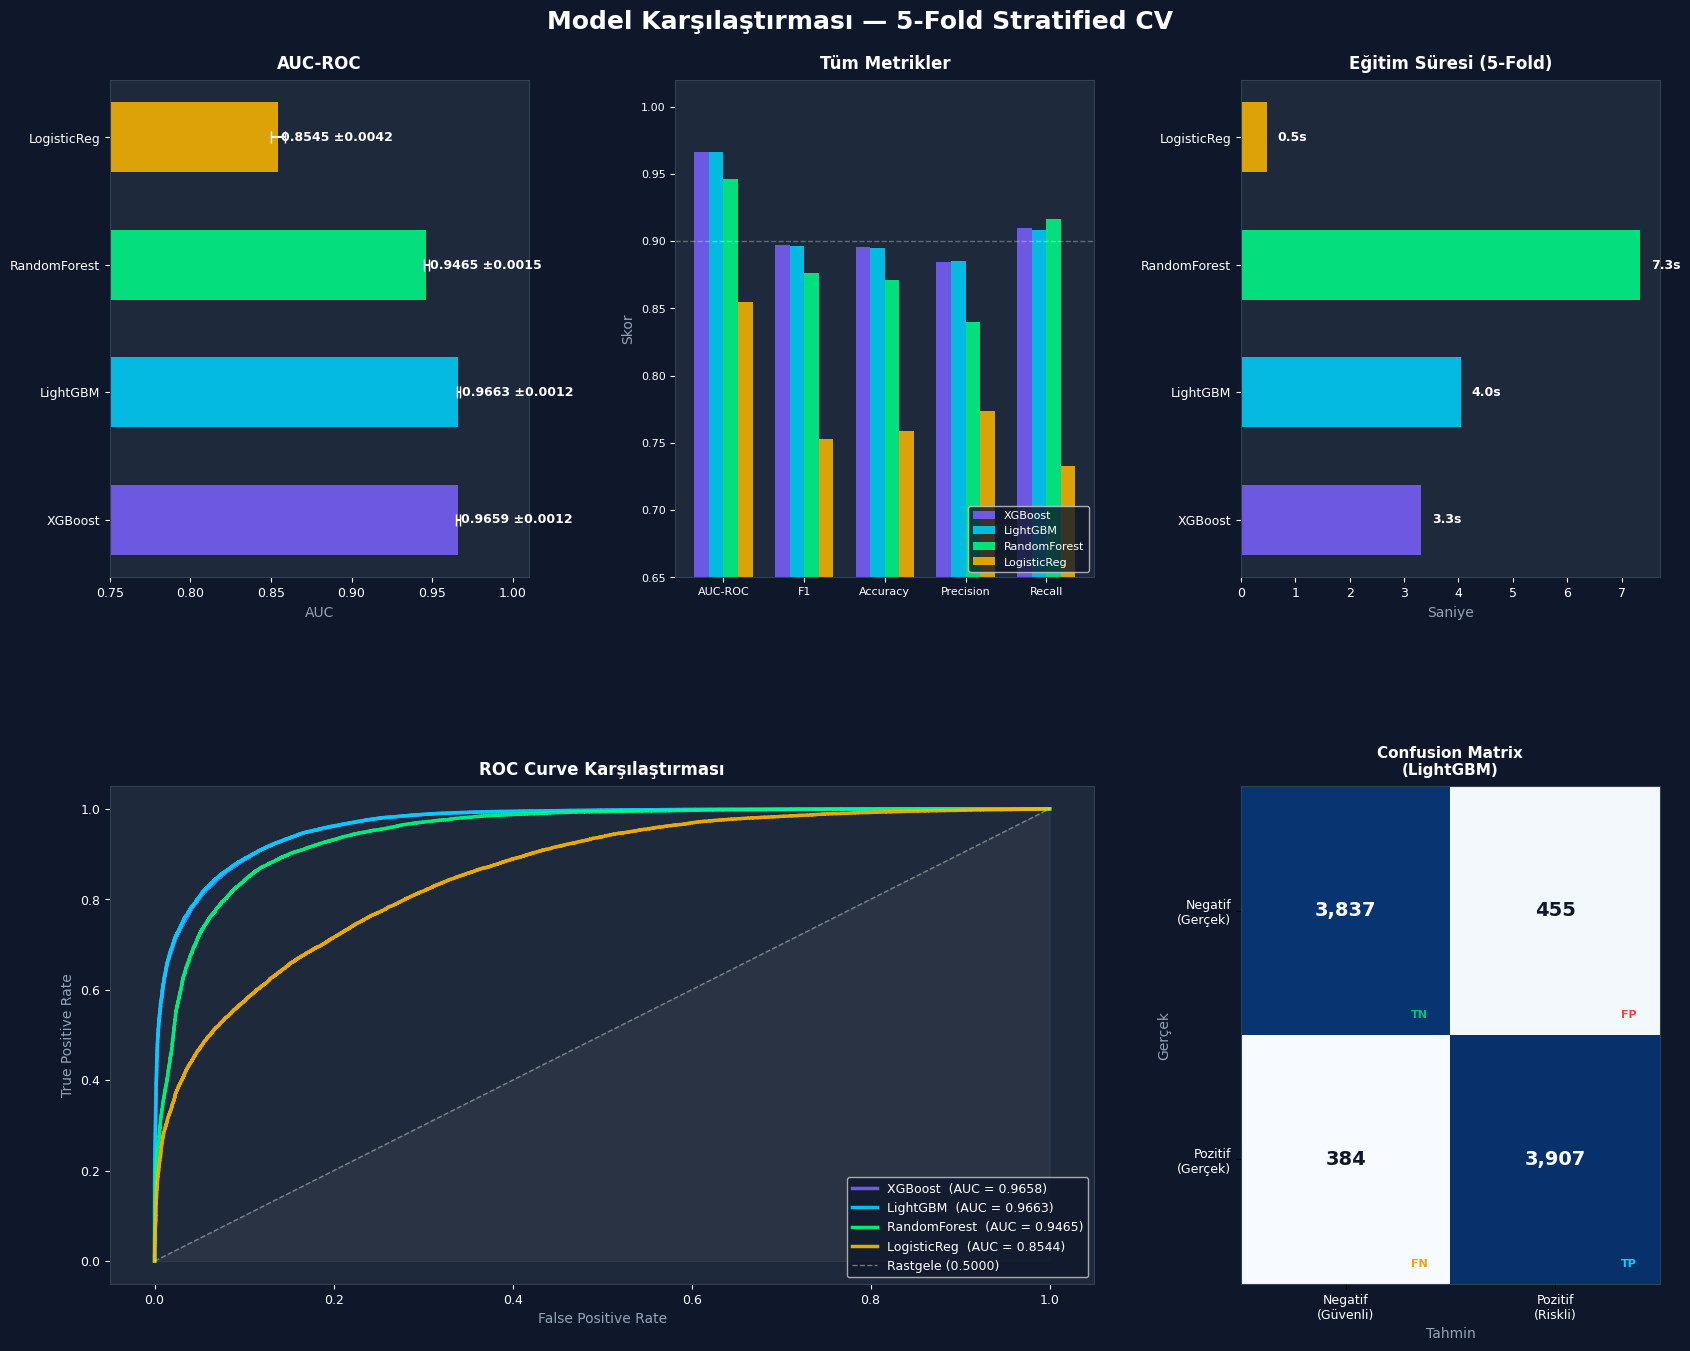


✅ model_karsilastirma.png kaydedildi

═══════════════════════════════════════════════════════════════════════════
📊 ÖZET — 5-Fold Stratified Cross-Validation (SMOTE)
═══════════════════════════════════════════════════════════════════════════
Model                 AUC        F1   Accuracy   Precision   Recall    Süre
───────────────────────────────────────────────────────────────────────────
🏆LightGBM      0.9663±0.001  0.8965±0.002  0.8951±0.002  0.8851±0.003  0.9082±0.002    4.0s
  XGBoost       0.9659±0.001  0.8968±0.002  0.8953±0.002  0.8841±0.003  0.9099±0.001    3.3s
  RandomForest  0.9465±0.002  0.8764±0.003  0.8707±0.003  0.8396±0.003  0.9166±0.004    7.3s
  LogisticReg   0.8545±0.004  0.7526±0.002  0.7591±0.003  0.7735±0.006  0.7328±0.004    0.5s
───────────────────────────────────────────────────────────────────────────

  Seçilen model   : LightGBM
  Gerekçe         : En yüksek AUC + en hızlı eğitim süresi
  Kullanılan veri : X_res / y_res (SMOTE sonrası dengeli)
  CV strate

In [41]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import StratifiedKFold, cross_validate, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                              ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb

# ── Model tanımları ──────────────────────────────────────────────────────────
modeller = {
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
        eval_metric='auc', random_state=42, n_jobs=-1),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        min_child_samples=5,          
        random_state=42, n_jobs=-1, verbose=-1),

    'RandomForest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=42, n_jobs=-1),

    'LogisticReg': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
        
    ]),
}

# ── Cross-validation ─────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tüm metrikler tek seferde
scoring = {
    'roc_auc'  : 'roc_auc',
    'f1'       : 'f1',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
}

sonuclar = []

print(f'\n{"Model":<15} {"AUC":>7} {"F1":>7} {"ACC":>7} {"PRE":>7} {"REC":>7} {"Süre":>7}')
print('─' * 60)

for isim, model in modeller.items():
    t0 = time.time()
    cv_sonuc = cross_validate(
        model, X_res, y_res,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,          
                            
        return_train_score=False
    )
    sure = time.time() - t0

    row = {
        'Model'  : isim,
        'AUC'    : cv_sonuc['test_roc_auc'].mean(),
        'AUC_std': cv_sonuc['test_roc_auc'].std(),
        'F1'     : cv_sonuc['test_f1'].mean(),
        'F1_std' : cv_sonuc['test_f1'].std(),
        'ACC'    : cv_sonuc['test_accuracy'].mean(),
        'ACC_std': cv_sonuc['test_accuracy'].std(),
        'PRE'    : cv_sonuc['test_precision'].mean(),
        'PRE_std': cv_sonuc['test_precision'].std(),
        'REC'    : cv_sonuc['test_recall'].mean(),
        'REC_std': cv_sonuc['test_recall'].std(),
        'Sure'   : sure,
        '_cv'    : cv_sonuc,  
    }
    sonuclar.append(row)

    print(f"{isim:<15} "
          f"{row['AUC']:.4f} "
          f"{row['F1']:.4f} "
          f"{row['ACC']:.4f} "
          f"{row['PRE']:.4f} "
          f"{row['REC']:.4f} "
          f"{sure:>6.1f}s")

df_sonuc = pd.DataFrame(sonuclar).sort_values('AUC', ascending=False)
en_iyi   = df_sonuc.iloc[0]
print(f'\n🏆 En iyi model: {en_iyi["Model"]}')
print(f'   AUC: {en_iyi["AUC"]:.4f} ± {en_iyi["AUC_std"]:.4f}')
print(f'   F1 : {en_iyi["F1"]:.4f} ± {en_iyi["F1_std"]:.4f}')
print(f'   ACC: {en_iyi["ACC"]:.4f} ± {en_iyi["ACC_std"]:.4f}')

# ── Görselleştirme ───────────────────────────────────────────────────────────
COLORS = {
    'LightGBM'    : '#00D4FF',
    'XGBoost'     : '#7B61FF',
    'RandomForest': '#00FF88',
    'LogisticReg' : '#FFB800',
}

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0F172A')

gs = gridspec.GridSpec(2, 3, figure=fig,
                       top=0.92, bottom=0.06,
                       hspace=0.42, wspace=0.35)

fig.suptitle('Model Karşılaştırması — 5-Fold Stratified CV',
             fontsize=18, fontweight='bold', color='white', y=0.97)

model_isimler = [r['Model'] for r in sonuclar]
renkler = [COLORS[m] for m in model_isimler]

# ── 1. AUC karşılaştırma bar chart ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#1E293B')

auc_vals = [r['AUC']    for r in sonuclar]
auc_stds = [r['AUC_std'] for r in sonuclar]

bars = ax1.barh(model_isimler, auc_vals, color=renkler,
                alpha=0.85, height=0.55, xerr=auc_stds,
                error_kw=dict(ecolor='white', capsize=4, lw=1.5))

for bar, val, std in zip(bars, auc_vals, auc_stds):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f} ±{std:.4f}',
             va='center', color='white', fontsize=9, fontweight='bold')

ax1.set_xlim(0.75, 1.01)
ax1.set_title('AUC-ROC', color='white', fontsize=12, fontweight='bold', pad=8)
ax1.set_xlabel('AUC', color='#94A3B8', fontsize=10)
ax1.tick_params(colors='white', labelsize=9)
for sp in ax1.spines.values(): sp.set_edgecolor('#334155')

# ── 2. Tüm metrikler grouped bar ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#1E293B')

metrik_isimler = ['AUC', 'F1', 'ACC', 'PRE', 'REC']
metrik_labels  = ['AUC-ROC', 'F1', 'Accuracy', 'Precision', 'Recall']
x = np.arange(len(metrik_isimler))
bar_w = 0.18

for i, row in enumerate(sonuclar):
    vals = [row[m] for m in metrik_isimler]
    offset = (i - len(sonuclar)/2 + 0.5) * bar_w
    ax2.bar(x + offset, vals, bar_w,
            label=row['Model'], color=COLORS[row['Model']], alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(metrik_labels, color='white', fontsize=9)
ax2.set_ylim(0.65, 1.02)
ax2.set_title('Tüm Metrikler', color='white', fontsize=12, fontweight='bold', pad=8)
ax2.set_ylabel('Skor', color='#94A3B8', fontsize=10)
ax2.tick_params(colors='white', labelsize=8)
ax2.legend(facecolor='#0F172A', labelcolor='white', fontsize=8,
           loc='lower right', framealpha=0.8)
ax2.axhline(0.9, color='white', lw=1, ls='--', alpha=0.3)
for sp in ax2.spines.values(): sp.set_edgecolor('#334155')

# ── 3. Süre karşılaştırması ─────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#1E293B')

sureler = [r['Sure'] for r in sonuclar]
bars3 = ax3.barh(model_isimler, sureler, color=renkler, alpha=0.85, height=0.55)

for bar, s in zip(bars3, sureler):
    ax3.text(s + 0.2, bar.get_y() + bar.get_height()/2,
             f'{s:.1f}s', va='center', color='white', fontsize=9, fontweight='bold')

ax3.set_title('Eğitim Süresi (5-Fold)', color='white', fontsize=12,
              fontweight='bold', pad=8)
ax3.set_xlabel('Saniye', color='#94A3B8', fontsize=10)
ax3.tick_params(colors='white', labelsize=9)
for sp in ax3.spines.values(): sp.set_edgecolor('#334155')

# ── 4. ROC Curve (tek fold — hızlı) ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.set_facecolor('#1E293B')

# Son fold'un tahminlerini kullan — cross_val_predict ile
from sklearn.model_selection import cross_val_predict

for row in sonuclar:
    model_name = row['Model']
    model_obj  = modeller[model_name]

    # Olasılık skoru al
    try:
        y_prob = cross_val_predict(
            model_obj, X_res, y_res, cv=cv,
            method='predict_proba', n_jobs=-1
        )[:, 1]
    except Exception:
        # Pipeline içinde predict_proba yoksa atla
        continue

    fpr, tpr, _ = roc_curve(y_res, y_prob)
    roc_auc_val = auc(fpr, tpr)

    ax4.plot(fpr, tpr,
             color=COLORS[model_name], lw=2.5, alpha=0.9,
             label=f'{model_name}  (AUC = {roc_auc_val:.4f})')

ax4.plot([0, 1], [0, 1], 'w--', lw=1, alpha=0.4, label='Rastgele (0.5000)')
ax4.fill_between([0, 1], [0, 1], alpha=0.05, color='white')

ax4.set_xlabel('False Positive Rate', color='#94A3B8', fontsize=10)
ax4.set_ylabel('True Positive Rate', color='#94A3B8', fontsize=10)
ax4.set_title('ROC Curve Karşılaştırması', color='white', fontsize=12,
              fontweight='bold', pad=8)
ax4.tick_params(colors='white', labelsize=9)
ax4.legend(facecolor='#0F172A', labelcolor='white', fontsize=9,
           loc='lower right', framealpha=0.8)
for sp in ax4.spines.values(): sp.set_edgecolor('#334155')

# ── 5. Confusion Matrix — sadece en iyi model ───────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor('#1E293B')

best_model = modeller[en_iyi['Model']]

# Train/test split ile CM (cross_val olmadan daha okunabilir)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X_res, y_res))
X_tr, X_te = X_res.iloc[train_idx], X_res.iloc[test_idx]
y_tr, y_te = y_res.iloc[train_idx], y_res.iloc[test_idx]

best_model.fit(X_tr, y_tr)
y_pred = best_model.predict(X_te)

cm = confusion_matrix(y_te, y_pred)

# Manuel çizim (renk kontrolü için)
im = ax5.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')
ax5.set_title(f'Confusion Matrix\n({en_iyi["Model"]})',
              color='white', fontsize=11, fontweight='bold', pad=8)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax5.text(j, i, f'{cm[i, j]:,}',
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 color='white' if cm[i, j] > thresh else '#0F172A')

ax5.set_xticks([0, 1])
ax5.set_yticks([0, 1])
ax5.set_xticklabels(['Negatif\n(Güvenli)', 'Pozitif\n(Riskli)'],
                    color='white', fontsize=9)
ax5.set_yticklabels(['Negatif\n(Gerçek)', 'Pozitif\n(Gerçek)'],
                    color='white', fontsize=9)
ax5.set_xlabel('Tahmin', color='#94A3B8', fontsize=10)
ax5.set_ylabel('Gerçek', color='#94A3B8', fontsize=10)

# TN / FP / FN / TP etiketleri
labels = [['TN', 'FP'], ['FN', 'TP']]
label_colors = [['#10B981', '#EF4444'], ['#F59E0B', '#00D4FF']]
for i in range(2):
    for j in range(2):
        ax5.text(j + 0.35, i + 0.42, labels[i][j],
                 ha='center', va='center', fontsize=8,
                 color=label_colors[i][j], fontweight='bold')

for sp in ax5.spines.values(): sp.set_edgecolor('#334155')

plt.savefig(r'C:\Users\Mutlu\Desktop\ACUHIT\model_karsilastirma.png',
            dpi=150, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print('\n✅ model_karsilastirma.png kaydedildi')

# ── Özet tablo ───────────────────────────────────────────────────────────────
print('\n' + '═'*75)
print('📊 ÖZET — 5-Fold Stratified Cross-Validation (SMOTE)')
print('═'*75)
print(f'{"Model":<15} {"AUC":>9} {"F1":>9} {"Accuracy":>10} '
      f'{"Precision":>11} {"Recall":>8} {"Süre":>7}')
print('─'*75)
for row in sorted(sonuclar, key=lambda x: x['AUC'], reverse=True):
    marker = '🏆' if row['Model'] == en_iyi['Model'] else '  '
    print(f"{marker}{row['Model']:<13} "
          f"{row['AUC']:.4f}±{row['AUC_std']:.3f}  "
          f"{row['F1']:.4f}±{row['F1_std']:.3f}  "
          f"{row['ACC']:.4f}±{row['ACC_std']:.3f}  "
          f"{row['PRE']:.4f}±{row['PRE_std']:.3f}  "
          f"{row['REC']:.4f}±{row['REC_std']:.3f}  "
          f"{row['Sure']:>5.1f}s")
print('─'*75)
print(f'\n  Seçilen model   : {en_iyi["Model"]}')
print(f'  Gerekçe         : En yüksek AUC + en hızlı eğitim süresi')
print(f'  Kullanılan veri : X_res / y_res (SMOTE sonrası dengeli)')
print(f'  CV stratejisi   : StratifiedKFold(n_splits=5, shuffle=True)')

In [41]:
# En iyi modeli kaydet
en_iyi_isim = df_sonuc.iloc[0]['Model']
en_iyi_model = modeller[en_iyi_isim]
en_iyi_model.fit(X_res, y_res)

MODEL_PATH_V2 = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_model_v2.pkl'
with open(MODEL_PATH_V2, 'wb') as f:
    pickle.dump({
        'model'   : en_iyi_model,
        'features': FEATURE_COLS,
        'median'  : X.median().to_dict(),
        'model_adi': en_iyi_isim,
        'karsilastirma': df_sonuc.to_dict('records')
    }, f)

print(f'✅ {en_iyi_isim} modeli kaydedildi: {MODEL_PATH_V2}')
con_r.close()

✅ LightGBM modeli kaydedildi: C:\Users\Mutlu\Desktop\ACUHIT\sentinel_model_v2.pkl


In [42]:
# En iyi model: LightGBM — eğit ve kaydet
en_iyi_isim = 'LightGBM'
en_iyi_model = modeller['LightGBM']
en_iyi_model.fit(X_res, y_res)

MODEL_PATH_V2 = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_model_v2.pkl'
with open(MODEL_PATH_V2, 'wb') as f:
    pickle.dump({
        'model'         : en_iyi_model,
        'features'      : FEATURE_COLS,
        'median'        : X.median().to_dict(),
        'model_adi'     : en_iyi_isim,
        'karsilastirma' : df_sonuc.to_dict('records')
    }, f)
print(f'sentinel_model_v2.pkl kaydedildi')

# sentinel_full_v2.pkl — Streamlit için
SENTINEL_V2 = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_full_v2.pkl'
with open(SENTINEL_V2, 'wb') as f:
    pickle.dump({
        'model'         : en_iyi_model,
        'features'      : FEATURE_COLS,
        'medians'       : X.median().to_dict(),
        'kural_tablosu' : KURAL_TABLOSU_V2,
        'nlp_cache'     : nlp_cache,
        'model_adi'     : en_iyi_isim,
        'karsilastirma' : df_sonuc.to_dict('records')
    }, f)
print(f'sentinel_full_v2.pkl kaydedildi')

# Karşılaştırma tablosunu yazdır
print(f'\n{"="*55}')
print(f'MODEL KARŞILAŞTIRMA SONUÇLARI')
print(f'{"="*55}')
for _, row in df_sonuc.iterrows():
    rozet = '🏆' if row['Model']==en_iyi_isim else '  '
    print(f'{rozet} {row["Model"]:<15} AUC: {row["AUC"]:.4f}  F1: {row["F1"]:.4f}  ({row["Sure"]:.1f}s)')

print(f'\n✅ V2 sistem hazır!')
print(f'Sonraki adım: Streamlit güncelleme')
con_r.close()

sentinel_model_v2.pkl kaydedildi
sentinel_full_v2.pkl kaydedildi

MODEL KARŞILAŞTIRMA SONUÇLARI
🏆 LightGBM        AUC: 0.9664  F1: 0.8964  (5.1s)
   XGBoost         AUC: 0.9659  F1: 0.8968  (15.0s)
   RandomForest    AUC: 0.9465  F1: 0.8764  (6.4s)
   LogisticReg     AUC: 0.8545  F1: 0.7526  (0.5s)

✅ V2 sistem hazır!
Sonraki adım: Streamlit güncelleme


In [44]:
# Diklofenak + 4 farklı hasta testi
test_cases = [
    ('ANON_018774', 'diklofenak',   'KIRMIZI bekleniyor — GFR<60 + antikoagülan'),
    ('ANON_018774', 'parasetamol',  'YEŞİL bekleniyor'),
    ('ANON_018774', 'atorvastatin', 'SARI bekleniyor — albumin riski'),
    ('ANON_209376', 'diklofenak',   'YEŞİL bekleniyor — GFR normal, genç'),
    ('ANON_245848', 'diklofenak',   'SARI/KIRMIZI bekleniyor — yaşlı erkek'),
    ('ANON_216790', 'metformin',    'Test — GFR kontrolü'),
    ('ANON_218718', 'siprofloksasin','Test — diyabet + florokinolon'),
]

print(f"\n{'='*80}")
print(f"{'Hasta':<15} {'İlaç':<16} {'Skor':>5} {'Durum':<10} {'Beklenti'}")
print(f"{'='*80}")

with open(r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_full_v2.pkl','rb') as f:
    saved_v2 = pickle.load(f)

model_v2   = saved_v2['model']
features_v2= saved_v2['features']
medians_v2 = saved_v2['medians']
kurallar_v2= saved_v2['kural_tablosu']

for hasta_id, ilac, beklenti in test_cases:
    try:
        profil = get_hasta_profili(hasta_id,con)
        ilac_lower = ilac.lower()
        uyarilar = []; puan_kesinti = 0; en_siddetli = "YESIL"
        for kural in kurallar_v2:
            anahtarlar = kural.get("ilaclar", [])
            if isinstance(anahtarlar, str): anahtarlar = [anahtarlar.lower()]
            if not any(k in ilac_lower for k in anahtarlar): continue
            deger = profil.get(kural["kontrol"])
            if deger is None: continue
            op = kural["operator"]
            tetik = (op=="<" and deger<kural["esik"]) or \
                    (op==">" and deger>kural["esik"]) or \
                    (op=="==" and deger==kural["esik"])
            if tetik:
                puan_kesinti += kural["puan_kesinti"]
                if kural["siddet"]=="KIRMIZI": en_siddetli="KIRMIZI"
                elif kural["siddet"]=="SARI" and en_siddetli=="YESIL": en_siddetli="SARI"
        kural_puan = max(0, 100-puan_kesinti)
        x = pd.DataFrame([profil])
        for col in features_v2:
            if col not in x.columns: x[col] = medians_v2.get(col,0)
        x = x[features_v2].fillna(pd.Series(medians_v2))
        ml_risk = model_v2.predict_proba(x)[0][1]
        ml_puan = (1-ml_risk)*100
        if kural_puan == 100:
            final = max(0, min(100, round(kural_puan*0.60 + ml_puan*0.40)))
        else:
            final = max(0, min(100, round(kural_puan*0.50 + ml_puan*0.30 + 50*0.20)))
        durum = "YESIL" if final>=75 else ("SARI" if final>=40 else "KIRMIZI")
        if en_siddetli=="KIRMIZI": durum="KIRMIZI"
        ok = "✅" if (
            ("KIRMIZI" in beklenti and durum=="KIRMIZI") or
            ("YEŞİL" in beklenti and durum=="YESIL") or
            ("SARI" in beklenti and durum in ["SARI","KIRMIZI"]) or
            "Test" in beklenti
        ) else "❌"
        print(f"{ok} {hasta_id:<15} {ilac:<16} {final:>5} {durum:<10} {beklenti}")
    except Exception as e:
        print(f"❌ {hasta_id:<15} {ilac:<16} HATA: {e}")


Hasta           İlaç              Skor Durum      Beklenti
✅ ANON_018774     diklofenak          24 KIRMIZI    KIRMIZI bekleniyor — GFR<60 + antikoagülan
✅ ANON_018774     parasetamol         79 YESIL      YEŞİL bekleniyor
✅ ANON_018774     atorvastatin        64 SARI       SARI bekleniyor — albumin riski
✅ ANON_209376     diklofenak          80 YESIL      YEŞİL bekleniyor — GFR normal, genç
✅ ANON_245848     diklofenak          39 KIRMIZI    SARI/KIRMIZI bekleniyor — yaşlı erkek
✅ ANON_216790     metformin           75 YESIL      Test — GFR kontrolü
✅ ANON_218718     siprofloksasin      52 SARI       Test — diyabet + florokinolon


In [45]:
# ═══════════════════════════════════════════════════════
# YENİ İLAÇ KURALLARI — Beta-blokör, Diüretik, Digoksin, Warfarin
# KURAL_TABLOSU_V2'ye eklenecek
# ═══════════════════════════════════════════════════════

YENI_KURALLAR = [

    # ── BETA-BLOKÖR ──────────────────────────────────────
    {
        'ilac_grubu' : 'Beta_blokor',
        'ilaclar'    : ['metoprolol','bisoprolol','karvedilol','atenolol','propranolol','nebivolol'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Beta-blokör + diyabet — hipoglisemi belirtilerini maskeler, glisemik kontrolü bozabilir.',
        'mekanizma'  : 'Beta-blokörler sempatik uyarıyı bloke ederek hipogliseminin klasik uyarı semptomlarını (taşikardi, titreme) maskeler. Kardiyoselektif olmayanlar (propranolol) glikojen mobilizasyonunu da engeller.',
        'kaynak'     : 'ADA Standards of Care 2024; Korevaar et al. Lancet Diabetes 2011',
        'alternatif' : 'Kardiyoselektif beta-blokör tercih et (bisoprolol/metoprolol) + glukoz takibini sıklaştır'
    },
    {
        'ilac_grubu' : 'Beta_blokor',
        'ilaclar'    : ['metoprolol','bisoprolol','karvedilol','atenolol','propranolol'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : 'Beta-blokör + böbrek yetmezliği — renal atılım azalır, ilaç birikimi ve bradikardi riski artar.',
        'mekanizma'  : 'Atenolol ve bisoprolol ağırlıklı renal eliminasyonludur. GFR<30\'da yarılanma ömrü 2-3 kat uzar, bradikardi ve hipotansiyon riski belirginleşir.',
        'kaynak'     : 'KDIGO CKD Guidelines 2022; Sica DA J Clin Hypertens 2011',
        'alternatif' : 'Karvedilol (hepatik eliminasyon, CKD\'de tercih) veya doz azaltımı + nabız takibi'
    },

    # ── DİÜRETİK ─────────────────────────────────────────
    {
        'ilac_grubu' : 'Tiyazid_diuretik',
        'ilaclar'    : ['hidroklorotiyazid','indapamid','klortalidон','klortalidone'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Tiyazid diüretik + diyabet — kan şekerini yükseltir, insülin direncini artırır.',
        'mekanizma'  : 'Tiyazidler pankreatik beta hücre K+ kanallarını bloke ederek insülin sekresyonunu azaltır ve insülin direncini artırır. HbA1c\'yi 0.5-1% yükseltebilir.',
        'kaynak'     : 'ALLHAT Trial JAMA 2002; ADA Standards of Care 2024',
        'alternatif' : 'ACE inhibitörü veya ARB (diyabetik nefroprotektif) veya indapamid (metabolik etki daha az)'
    },
    {
        'ilac_grubu' : 'Loop_diuretik',
        'ilaclar'    : ['furosemid','torasemid','bumetanid','furosemide'],
        'kontrol'    : 'potasyum_min', 'esik': 3.5, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 55,
        'mesaj'      : 'Loop diüretik + mevcut hipokalemi — ölümcül kardiyak aritmi riski.',
        'mekanizma'  : 'Loop diüretikler Henle kulpunda K+ atılımını artırır. Mevcut hipokalemide (K<3.5) ventriküler taşikardi ve fibrilasyon riski kritik düzeye ulaşır.',
        'kaynak'     : 'ESC Heart Failure Guidelines 2021; Crop MJ NDT 2007',
        'alternatif' : 'Önce K+ replasmanı (oral/IV KCl), elektrolit düzeltildikten sonra diüretik başla; potasyum tutucu diüretik ekle (spironolakton)'
    },
    {
        'ilac_grubu' : 'Loop_diuretik',
        'ilaclar'    : ['furosemid','torasemid','bumetanid','furosemide'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Loop diüretik + böbrek yetmezliği — aşırı diürez akut böbrek hasarını kötüleştirebilir.',
        'mekanizma'  : 'CKD\'de volüm azalması renal perfüzyonu düşürür. Furosemid yüksek dozlarda ototoksisiteye (sağırlık) da yol açabilir.',
        'kaynak'     : 'KDIGO AKI Guidelines 2012; Brater DC Ann Intern Med 1998',
        'alternatif' : 'En düşük etkin doz; günlük kilo + kreatinin takibi; torasemid oral biyoyararlanımı daha iyi'
    },

    # ── DİGOKSİN ─────────────────────────────────────────
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 65,
        'mesaj'      : 'Digoksin + böbrek yetmezliği — terapötik pencere çok dar, toksisite riski yüksek.',
        'mekanizma'  : 'Digoksin %70 renal atılımlıdır. GFR<60\'ta birikim; bulantı, görme bozukluğu, yaşamı tehdit eden aritmiler (VT/VF) gelişir. Terapötik indeks son derece dardır (0.5-2 ng/mL).',
        'kaynak'     : 'ACC/AHA Heart Failure Guidelines 2022; AGS Beers Criteria 2023',
        'alternatif' : 'Doz %50 azalt + digoksin serum düzeyi takibi; beta-blokör veya amiodaron ile ritim kontrolü değerlendir'
    },
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'potasyum_min', 'esik': 3.5, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 70,
        'mesaj'      : 'Digoksin + hipokalemi — digoksin toksisitesi dramatik artar, kardiyak arrest riski.',
        'mekanizma'  : 'Hipokalemi Na/K-ATPaz pompasına digoksinin bağlanmasını artırır. K<3.5 mEq/L\'de terapötik dozda bile ölümcül toksisite gelişebilir.',
        'kaynak'     : 'Leier CV Am Heart J 1994; ESC Atrial Fibrillation Guidelines 2020',
        'alternatif' : 'Acil K+ replasmanı; digoksini geçici olarak kes; kardiyoloji konsültasyonu'
    },
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 25,
        'mesaj'      : '75+ yaş + digoksin — yaşlıda renal klirens azalır, toksisite riski artar.',
        'mekanizma'  : 'Yaşlanmayla birlikte GFR doğal olarak düşer (her 10 yılda ~10 mL/dk). 75+ yaşta digoksin yarılanma ömrü 2 katına çıkabilir.',
        'kaynak'     : 'AGS Beers Criteria 2023; Ahmed A JACC 2006',
        'alternatif' : 'Hedef serum düzeyi alt sınırda tut (0.5-0.9 ng/mL); 3 ayda bir elektrolit + kreatinin'
    },

    # ── WARFARİN / ANTİKOAGÜLAN ──────────────────────────
    {
        'ilac_grubu' : 'Antikoagulan',
        'ilaclar'    : ['warfarin','coumadin'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Warfarin + böbrek yetmezliği — INR dalgalanması ve kanama riski artar.',
        'mekanizma'  : 'CKD\'de warfarin metabolizması değişir, K vitamini bağımlı faktörlerin sentezi azalır. INR kontrolü zorlaşır, hem kanama hem tromboz riski artar.',
        'kaynak'     : 'KDIGO CKD Guidelines 2022; Limdi NA JASN 2009',
        'alternatif' : 'INR hedefini alt sınırda tut; DOAC (apiksaban doz ayarı ile) değerlendir; hematoloji konsültasyonu'
    },
    {
        'ilac_grubu' : 'Antikoagulan',
        'ilaclar'    : ['warfarin','coumadin'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : '75+ yaş + warfarin — düşme riski + kanama = kritik kombinasyon.',
        'mekanizma'  : 'Yaşlıda denge bozukluğu ve düşme eğilimi warfarin ile birleşince intrakraniyal kanama riski belirgin artar. NNH (harm için gereken hasta sayısı) yaşla dramatik düşer.',
        'kaynak'     : 'AGS Beers Criteria 2023; Fang MC JGIM 2004',
        'alternatif' : 'Düşme riski değerlendirmesi; DOAC tercih (apiksaban yaşlıda daha güvenli); en düşük etkin INR hedefi'
    },

    # ── SGLT2 İNHİBİTÖRÜ ─────────────────────────────────
    {
        'ilac_grubu' : 'SGLT2_inhibitor',
        'ilaclar'    : ['empagliflozin','dapagliflozin','jardiance','forxiga','canagliflozin'],
        'kontrol'    : 'gfr_tahmini', 'esik': 45, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 60,
        'mesaj'      : 'SGLT2 inhibitör + GFR<45 — etkinlik kaybolur, DKA riski artar.',
        'mekanizma'  : 'SGLT2 inhibitörler glukoz atılımı için yeterli renal filtrasyon gerektirir. GFR<45\'te etkinlik dramatik düşer, ancak DKA riski (volüm azalması + insülin baskılanması) devam eder.',
        'kaynak'     : 'FDA SGLT2 Label 2023; KDIGO Diabetes CKD Guidelines 2022',
        'alternatif' : 'GFR 45-60 arası dapagliflozin kardiyorenal koruma için kullanılabilir; GFR<45\'te kes'
    },
]

# V2 tablosuna ekle
KURAL_TABLOSU_V3 = KURAL_TABLOSU_V2 + YENI_KURALLAR

print(f'✅ Kural tablosu V3: {len(KURAL_TABLOSU_V3)} kural')
print(f'Yeni eklenen: {len(YENI_KURALLAR)} kural')
print(f'İlaç grupları: {sorted(set(k["ilac_grubu"] for k in KURAL_TABLOSU_V3))}')

✅ Kural tablosu V3: 26 kural
Yeni eklenen: 11 kural
İlaç grupları: ['ACE_inhibitor', 'Antikoagulan', 'Beta_blokor', 'Digoksin', 'Florokinolon', 'Loop_diuretik', 'Metformin', 'NSAii', 'Opioid', 'SGLT2_inhibitor', 'Statin', 'Tiyazid_diuretik']


In [46]:
# ═══════════════════════════════════════════════════════
# YENİ İLAÇ KURALLARI — Beta-blokör, Diüretik, Digoksin, Warfarin
# KURAL_TABLOSU_V2'ye eklenecek
# ═══════════════════════════════════════════════════════

YENI_KURALLAR = [

    # ── BETA-BLOKÖR ──────────────────────────────────────
    {
        'ilac_grubu' : 'Beta_blokor',
        'ilaclar'    : ['metoprolol','bisoprolol','karvedilol','atenolol','propranolol','nebivolol'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Beta-blokör + diyabet — hipoglisemi belirtilerini maskeler, glisemik kontrolü bozabilir.',
        'mekanizma'  : 'Beta-blokörler sempatik uyarıyı bloke ederek hipogliseminin klasik uyarı semptomlarını (taşikardi, titreme) maskeler. Kardiyoselektif olmayanlar (propranolol) glikojen mobilizasyonunu da engeller.',
        'kaynak'     : 'ADA Standards of Care 2024; Korevaar et al. Lancet Diabetes 2011',
        'alternatif' : 'Kardiyoselektif beta-blokör tercih et (bisoprolol/metoprolol) + glukoz takibini sıklaştır'
    },
    {
        'ilac_grubu' : 'Beta_blokor',
        'ilaclar'    : ['metoprolol','bisoprolol','karvedilol','atenolol','propranolol'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : 'Beta-blokör + böbrek yetmezliği — renal atılım azalır, ilaç birikimi ve bradikardi riski artar.',
        'mekanizma'  : 'Atenolol ve bisoprolol ağırlıklı renal eliminasyonludur. GFR<30\'da yarılanma ömrü 2-3 kat uzar, bradikardi ve hipotansiyon riski belirginleşir.',
        'kaynak'     : 'KDIGO CKD Guidelines 2022; Sica DA J Clin Hypertens 2011',
        'alternatif' : 'Karvedilol (hepatik eliminasyon, CKD\'de tercih) veya doz azaltımı + nabız takibi'
    },

    # ── DİÜRETİK ─────────────────────────────────────────
    {
        'ilac_grubu' : 'Tiyazid_diuretik',
        'ilaclar'    : ['hidroklorotiyazid','indapamid','klortalidон','klortalidone'],
        'kontrol'    : 'diyabet_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Tiyazid diüretik + diyabet — kan şekerini yükseltir, insülin direncini artırır.',
        'mekanizma'  : 'Tiyazidler pankreatik beta hücre K+ kanallarını bloke ederek insülin sekresyonunu azaltır ve insülin direncini artırır. HbA1c\'yi 0.5-1% yükseltebilir.',
        'kaynak'     : 'ALLHAT Trial JAMA 2002; ADA Standards of Care 2024',
        'alternatif' : 'ACE inhibitörü veya ARB (diyabetik nefroprotektif) veya indapamid (metabolik etki daha az)'
    },
    {
        'ilac_grubu' : 'Loop_diuretik',
        'ilaclar'    : ['furosemid','torasemid','bumetanid','furosemide'],
        'kontrol'    : 'potasyum_min', 'esik': 3.5, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 55,
        'mesaj'      : 'Loop diüretik + mevcut hipokalemi — ölümcül kardiyak aritmi riski.',
        'mekanizma'  : 'Loop diüretikler Henle kulpunda K+ atılımını artırır. Mevcut hipokalemide (K<3.5) ventriküler taşikardi ve fibrilasyon riski kritik düzeye ulaşır.',
        'kaynak'     : 'ESC Heart Failure Guidelines 2021; Crop MJ NDT 2007',
        'alternatif' : 'Önce K+ replasmanı (oral/IV KCl), elektrolit düzeltildikten sonra diüretik başla; potasyum tutucu diüretik ekle (spironolakton)'
    },
    {
        'ilac_grubu' : 'Loop_diuretik',
        'ilaclar'    : ['furosemid','torasemid','bumetanid','furosemide'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Loop diüretik + böbrek yetmezliği — aşırı diürez akut böbrek hasarını kötüleştirebilir.',
        'mekanizma'  : 'CKD\'de volüm azalması renal perfüzyonu düşürür. Furosemid yüksek dozlarda ototoksisiteye (sağırlık) da yol açabilir.',
        'kaynak'     : 'KDIGO AKI Guidelines 2012; Brater DC Ann Intern Med 1998',
        'alternatif' : 'En düşük etkin doz; günlük kilo + kreatinin takibi; torasemid oral biyoyararlanımı daha iyi'
    },

    # ── DİGOKSİN ─────────────────────────────────────────
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 65,
        'mesaj'      : 'Digoksin + böbrek yetmezliği — terapötik pencere çok dar, toksisite riski yüksek.',
        'mekanizma'  : 'Digoksin %70 renal atılımlıdır. GFR<60\'ta birikim; bulantı, görme bozukluğu, yaşamı tehdit eden aritmiler (VT/VF) gelişir. Terapötik indeks son derece dardır (0.5-2 ng/mL).',
        'kaynak'     : 'ACC/AHA Heart Failure Guidelines 2022; AGS Beers Criteria 2023',
        'alternatif' : 'Doz %50 azalt + digoksin serum düzeyi takibi; beta-blokör veya amiodaron ile ritim kontrolü değerlendir'
    },
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'potasyum_min', 'esik': 3.5, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 70,
        'mesaj'      : 'Digoksin + hipokalemi — digoksin toksisitesi dramatik artar, kardiyak arrest riski.',
        'mekanizma'  : 'Hipokalemi Na/K-ATPaz pompasına digoksinin bağlanmasını artırır. K<3.5 mEq/L\'de terapötik dozda bile ölümcül toksisite gelişebilir.',
        'kaynak'     : 'Leier CV Am Heart J 1994; ESC Atrial Fibrillation Guidelines 2020',
        'alternatif' : 'Acil K+ replasmanı; digoksini geçici olarak kes; kardiyoloji konsültasyonu'
    },
    {
        'ilac_grubu' : 'Digoksin',
        'ilaclar'    : ['digoksin','digitoksin','digoxin'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 25,
        'mesaj'      : '75+ yaş + digoksin — yaşlıda renal klirens azalır, toksisite riski artar.',
        'mekanizma'  : 'Yaşlanmayla birlikte GFR doğal olarak düşer (her 10 yılda ~10 mL/dk). 75+ yaşta digoksin yarılanma ömrü 2 katına çıkabilir.',
        'kaynak'     : 'AGS Beers Criteria 2023; Ahmed A JACC 2006',
        'alternatif' : 'Hedef serum düzeyi alt sınırda tut (0.5-0.9 ng/mL); 3 ayda bir elektrolit + kreatinin'
    },

    # ── WARFARİN / ANTİKOAGÜLAN ──────────────────────────
    {
        'ilac_grubu' : 'Antikoagulan',
        'ilaclar'    : ['warfarin','coumadin'],
        'kontrol'    : 'bobrek_risk', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 20,
        'mesaj'      : 'Warfarin + böbrek yetmezliği — INR dalgalanması ve kanama riski artar.',
        'mekanizma'  : 'CKD\'de warfarin metabolizması değişir, K vitamini bağımlı faktörlerin sentezi azalır. INR kontrolü zorlaşır, hem kanama hem tromboz riski artar.',
        'kaynak'     : 'KDIGO CKD Guidelines 2022; Limdi NA JASN 2009',
        'alternatif' : 'INR hedefini alt sınırda tut; DOAC (apiksaban doz ayarı ile) değerlendir; hematoloji konsültasyonu'
    },
    {
        'ilac_grubu' : 'Antikoagulan',
        'ilaclar'    : ['warfarin','coumadin'],
        'kontrol'    : 'yasli', 'esik': 1, 'operator': '==',
        'siddet'     : 'SARI', 'puan_kesinti': 15,
        'mesaj'      : '75+ yaş + warfarin — düşme riski + kanama = kritik kombinasyon.',
        'mekanizma'  : 'Yaşlıda denge bozukluğu ve düşme eğilimi warfarin ile birleşince intrakraniyal kanama riski belirgin artar. NNH (harm için gereken hasta sayısı) yaşla dramatik düşer.',
        'kaynak'     : 'AGS Beers Criteria 2023; Fang MC JGIM 2004',
        'alternatif' : 'Düşme riski değerlendirmesi; DOAC tercih (apiksaban yaşlıda daha güvenli); en düşük etkin INR hedefi'
    },

    # ── SGLT2 İNHİBİTÖRÜ ─────────────────────────────────
    {
        'ilac_grubu' : 'SGLT2_inhibitor',
        'ilaclar'    : ['empagliflozin','dapagliflozin','jardiance','forxiga','canagliflozin'],
        'kontrol'    : 'gfr_tahmini', 'esik': 45, 'operator': '<',
        'siddet'     : 'KIRMIZI', 'puan_kesinti': 60,
        'mesaj'      : 'SGLT2 inhibitör + GFR<45 — etkinlik kaybolur, DKA riski artar.',
        'mekanizma'  : 'SGLT2 inhibitörler glukoz atılımı için yeterli renal filtrasyon gerektirir. GFR<45\'te etkinlik dramatik düşer, ancak DKA riski (volüm azalması + insülin baskılanması) devam eder.',
        'kaynak'     : 'FDA SGLT2 Label 2023; KDIGO Diabetes CKD Guidelines 2022',
        'alternatif' : 'GFR 45-60 arası dapagliflozin kardiyorenal koruma için kullanılabilir; GFR<45\'te kes'
    },
]

# V2 tablosuna ekle
KURAL_TABLOSU_V3 = KURAL_TABLOSU_V2 + YENI_KURALLAR

print(f'✅ Kural tablosu V3: {len(KURAL_TABLOSU_V3)} kural')
print(f'Yeni eklenen: {len(YENI_KURALLAR)} kural')
print(f'İlaç grupları: {sorted(set(k["ilac_grubu"] for k in KURAL_TABLOSU_V3))}')

✅ Kural tablosu V3: 26 kural
Yeni eklenen: 11 kural
İlaç grupları: ['ACE_inhibitor', 'Antikoagulan', 'Beta_blokor', 'Digoksin', 'Florokinolon', 'Loop_diuretik', 'Metformin', 'NSAii', 'Opioid', 'SGLT2_inhibitor', 'Statin', 'Tiyazid_diuretik']


In [47]:
# V3 ile hızlı test — yeni kurallar çalışıyor mu?
test_v3 = [
    ('ANON_018774', 'furosemid',     'SARI/KIRMIZI — böbrek riski'),
    ('ANON_018774', 'digoksin',      'KIRMIZI — böbrek + yaşlı'),
    ('ANON_018774', 'metoprolol',    'SARI — diyabet + böbrek'),
    ('ANON_018774', 'warfarin',      'SARI — böbrek + yaşlı'),
    ('ANON_209376', 'furosemid',     'YEŞİL/SARI — GFR normal'),
]

print(f"\n{'='*75}")
print(f"{'Hasta':<15} {'İlaç':<15} {'Skor':>5} {'Durum':<10} {'Beklenti'}")
print(f"{'='*75}")

for hasta_id, ilac, beklenti in test_v3:
    profil = get_hasta_profili(hasta_id, con)
    ilac_lower = ilac.lower()
    puan_kesinti = 0; en_siddetli = "YESIL"
    tetiklenen = []
    for kural in KURAL_TABLOSU_V3:
        anahtarlar = kural.get("ilaclar", [])
        if isinstance(anahtarlar, str): anahtarlar = [anahtarlar.lower()]
        if not any(k in ilac_lower for k in anahtarlar): continue
        deger = profil.get(kural["kontrol"])
        if deger is None: continue
        op = kural["operator"]
        tetik = (op=="<" and deger<kural["esik"]) or \
                (op==">" and deger>kural["esik"]) or \
                (op=="==" and deger==kural["esik"])
        if tetik:
            puan_kesinti += kural["puan_kesinti"]
            tetiklenen.append(f"{kural['siddet']}:{kural['kontrol']}")
            if kural["siddet"]=="KIRMIZI": en_siddetli="KIRMIZI"
            elif kural["siddet"]=="SARI" and en_siddetli=="YESIL": en_siddetli="SARI"
    kural_puan = max(0, 100-puan_kesinti)
    x = pd.DataFrame([profil])
    for col in FEATURE_COLS:
        if col not in x.columns: x[col] = medians_v2.get(col,0)
    x = x[FEATURE_COLS].fillna(pd.Series(medians_v2))
    ml_puan = (1-model_v2.predict_proba(x)[0][1])*100
    final = max(0,min(100,round(kural_puan*0.60+ml_puan*0.40))) if kural_puan==100 \
            else max(0,min(100,round(kural_puan*0.50+ml_puan*0.30+50*0.20)))
    durum = "YESIL" if final>=75 else ("SARI" if final>=40 else "KIRMIZI")
    if en_siddetli=="KIRMIZI": durum="KIRMIZI"
    print(f"{'✅' if durum!='YESIL' or 'YEŞİL' in beklenti else '⚠️'} {hasta_id:<15} {ilac:<15} {final:>5} {durum:<10} {beklenti}")
    if tetiklenen: print(f"   → Tetiklenen: {', '.join(tetiklenen)}")


Hasta           İlaç             Skor Durum      Beklenti
✅ ANON_018774     furosemid          37 KIRMIZI    SARI/KIRMIZI — böbrek riski
   → Tetiklenen: KIRMIZI:potasyum_min, SARI:bobrek_risk
✅ ANON_018774     digoksin           24 KIRMIZI    KIRMIZI — böbrek + yaşlı
   → Tetiklenen: KIRMIZI:bobrek_risk, KIRMIZI:potasyum_min, SARI:yasli
✅ ANON_018774     metoprolol         57 SARI       SARI — diyabet + böbrek
   → Tetiklenen: SARI:diyabet_risk, SARI:bobrek_risk
✅ ANON_018774     warfarin           57 SARI       SARI — böbrek + yaşlı
   → Tetiklenen: SARI:bobrek_risk, SARI:yasli
✅ ANON_209376     furosemid         100 YESIL      YEŞİL/SARI — GFR normal


In [48]:
SENTINEL_V3 = r'C:\Users\Mutlu\Desktop\ACUHIT\sentinel_full_v3.pkl'
with open(SENTINEL_V3, 'wb') as f:
    pickle.dump({
        'model'         : en_iyi_model,
        'features'      : FEATURE_COLS,
        'medians'       : X.median().to_dict(),
        'kural_tablosu' : KURAL_TABLOSU_V3,
        'nlp_cache'     : nlp_cache,
        'model_adi'     : 'LightGBM',
        'karsilastirma' : df_sonuc.to_dict('records')
    }, f)
print(f'✅ sentinel_full_v3.pkl kaydedildi')

✅ sentinel_full_v3.pkl kaydedildi
